In [1]:
# ML classes
from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager

# basics
from pathlib import Path
import re
from joblib import Parallel, delayed, dump, load
import pandas as pd
import numpy as np
import pickle
from tabulate import tabulate
from typing import Optional, Tuple, List, Dict, Union

# Plots
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
import matplotlib.axes as maxes

from lifelines.plotting import add_at_risk_counts

#ML
import xgboost as xgb
import shap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_predict, cross_val_score, LeaveOneOut, StratifiedKFold, KFold
from sklearn.feature_selection import mutual_info_classif, SelectKBest, VarianceThreshold, SelectFromModel, SelectPercentile
from sklearn import set_config
from sklearn.linear_model import LogisticRegression

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import statsmodels.api as sm

#Survival
from lifelines.utils import concordance_index, median_survival_times,find_best_parametric_model
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import rmst_plot, qq_plot,add_at_risk_counts
from lifelines import LogNormalFitter, LogLogisticFitter, WeibullFitter, ExponentialFitter, WeibullAFTFitter, KaplanMeierFitter, CoxPHFitter

from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw, concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.util import Surv

## Math
import math
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

import logging
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.family'] = 'Arial'

In [2]:
# Aggregate Feature Importances Across All Folds
def aggregate_feature_importances(importance_list):
    # Aggregate feature importance over multiple dictionaries
    all_keys = set(k for dic in importance_list for k in dic)
    aggregated_importance = {k: [] for k in all_keys}
    for dic in importance_list:
        for k in all_keys:
            aggregated_importance[k].append(dic.get(k, 0))

    # Calculate the mean for each feature
    mean_importance = {k: np.mean(v) for k, v in aggregated_importance.items()}
    return mean_importance


def c_index_scorer(y_true, y_pred) -> float:
    """
    Custom scorer to calculate Concordance Index (C-index) for single-column `y_true`.
    Negative values in `y_true` indicate censored data; positive values indicate events.

    Parameters:
    - y_true: 1D array of survival times (negative for censored, positive for events).
    - y_pred: Predicted risk scores (higher scores indicate higher risk).

    Returns:
    - C-index: Concordance Index for the predictions.
    """
    # Separate survival times and event indicators
    events = np.where(y_true < 0, 0, 1)  # 0 for censored, 1 for deceased
    times = np.abs(y_true)  #survival_time=np.abs(y_true) Absolute values for survival times
    #event_indicator = (y_true > 0).astype(int)  # 1 for events (positive values), 0 for censored (negative values)

    y_surv = Surv.from_arrays(event=events, time=times)

    # Calculate and return the C-index
    #return concordance_index(survival_time, -y_pred, event_indicator)
    #return concordance_index_ipcw(y_surv, y_surv, y_pred)[0]
    return concordance_index_censored(y_surv['event'], y_surv['time'], y_pred)[0]

def c_index_scorer_ipcw(y_train, y_val, y_pred):
    """
    Custom scorer to calculate Concordance Index (C-index).

    Parameters:
    - y_train: 1D array of survival times from training set (negative for censored, positive for events).
    - y_val: 1D array of survival times from validation set (negative for censored, positive for events).
    - y_pred: Predicted risk scores (higher scores indicate higher risk).

    Returns:
    - C-index: Concordance Index for the predictions.
    """

    # Separate survival times and event indicators
    train_events = np.where(y_train < 0, 0, 1)  # 0 for censored, 1 for deceased
    train_times = np.abs(y_train)  #survival_time=np.abs(y_true) Absolute values for survival times
    y_train_surv = Surv.from_arrays(event=train_events, time=train_times)

    val_events = np.where(y_val < 0, 0, 1)  # 0 for censored, 1 for deceased
    val_times = np.abs(y_val)  #survival_time=np.abs(y_true) Absolute values for survival times

    valid_indices = val_times <= train_times.max()
    val_events = val_events[valid_indices]
    val_times = val_times[valid_indices]

    y_val_surv = Surv.from_arrays(event=val_events, time=val_times)

    y_pred = y_pred[valid_indices]
    # Calculate and return the C-index
    return concordance_index_ipcw(y_train_surv, y_val_surv, y_pred)[0]


class CustomStratifiedKFold:
    def __init__(self, n_splits=5, shuffle=True, random_state=420):
        self.n_splits = n_splits
        self.skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    def split(self, X, y, groups=None):
        # Define labels based on the sign of y (negative for censored, positive for deceased)

        if isinstance(y, np.ndarray):  # y is a numpy array from Surv.from_arrays
            labels = y['event']  # Event status is the first column (event = 1, censored = 0)
        else:
            labels = np.where(y < 0, 0, 1)  # 0 for censored, 1 for deceased

        # Stratify based on these labels
        return self.skf.split(X, labels)

    def get_n_splits(self, X=None, y=None, groups=None):
        # We don't need to use the `groups` argument here, just return `n_splits`
        return self.n_splits


def search_best_model(estimator, param_grid, X_train, y_train, n_splits=5, n_iter=30, random_state=420, n_jobs = -1):
    # Create a custom scorer using C-index
    custom_scorer = make_scorer(c_index_scorer, greater_is_better=True)
    cv_inner = CustomStratifiedKFold(n_splits=n_splits, random_state=random_state)
    # search = RandomizedSearchCV(estimator, param_grid,
    #                                         cv=cv_inner, n_iter=n_iter,
    #                                         scoring=custom_scorer, refit=True,
    #                                         random_state=random_state, n_jobs=n_jobs)
    search = BayesSearchCV(estimator, search_spaces=param_grid,
                                cv=cv_inner,
                                n_iter=n_iter,
                                scoring=custom_scorer,
                                refit=True,
                                random_state=random_state,
                                n_jobs=n_jobs)

    search.fit(X_train, y_train)

    return search.best_estimator_

def generate_feature_importance_table(values: np.ndarray,
                                      features: pd.DataFrame,
                                      target: pd.Series,
                                      oligos_metadata: pd.DataFrame,
                                      group_tests: Optional[List[str]] = None,
                                      suffix_file: Optional[str] = None,
                                      with_oligos: bool = True,
                                      with_additional_features: bool = False,
                                      with_run_plates: bool = False,
                                      figures_dir: str = './') -> pd.DataFrame:
    """
    Create a feature importance table from SHAP values, optionally merging metadata
    and group prevalence statistics if group_tests is provided.

    Parameters
    ----------
    values : np.ndarray
        Array of SHAP values.
    features : pd.DataFrame
        DataFrame of  feature values used for group calculations with SampleName as index.
    target : pd.Series
        Series of target values with same indices as features (SampleName) and a column name.
    oligos_metadata : pd.DataFrame
        Metadata for the oligos (peptides), indexed by peptide ID.
    group_tests : Optional[List[str]], default None
        List of two strings representing group names. If provided, extra columns for prevalence and ratio are added.
    suffix_file : Optional[str], default None
        Name of the estimator (for filename).
    with_oligos : bool, default True
        Flag to include oligos metadata columns.
    with_additional_features : bool, default False
        Flag to include additional features.
    with_run_plates : bool, default False
        Flag to include run plate information.
    figures_dir : str, default './'
        Directory where the CSV file will be saved.

    Returns
    -------
    pd.DataFrame
        A DataFrame with feature importance (mean absolute SHAP values) merged with metadata,
        and if group_tests is provided, extra columns with group prevalence and ratio.
    """
    # Feature names
    features = features.join(target).set_index(target.name, append=True)
    colnames = features.columns

    # Create base table of feature importance sorted by mean absolute SHAP value.
    feature_shap_values_df = pd.DataFrame({'SHAP value': np.abs(values).mean(0)},
                                          index=colnames).sort_values(by='SHAP value', ascending=False)

    # Merge metadata (if available) and rename columns as desired.
    feature_shap_values_df = feature_shap_values_df.merge(
        oligos_metadata,
        left_index=True, right_index=True, how='left'
    ).rename(columns={'full name': 'Protein name', 'len_seq': 'Protein length',
                      'pos': 'Start position', 'Organism_complete_name': 'Organism'})

    # If group_tests is provided, compute additional prevalence and ratio columns.
    if group_tests is not None:
        # Filter columns based on keywords in colnames
        keywords = ['agilent', 'corona2', 'twist', 'Sex', 'Age', 'run_plate']
        pattern = '|'.join(keywords)
        filtered_index = colnames[colnames.str.contains(pattern, case=False, regex=True)]

        # Compute average (mean) prevalence per group at the second level of the index in 'features'
        percentiles = features[filtered_index].groupby(level=features.index.names[1]).mean()
        #percentiles = features.groupby(level=features.index.names[1]).mean()

        # Identify columns for which to convert to percentage
        get_perc_columns = percentiles.columns[
            percentiles.columns.str.contains('agilent|corona2|twist|sex|run_plate', case=False)]
        percentiles[get_perc_columns] = percentiles[get_perc_columns].mul(100)
        percentiles = percentiles.T.rename(columns={0: group_tests[0], 1: group_tests[1]})

        # Merge with our feature importance DataFrame.
        feature_shap_values_df = pd.merge(feature_shap_values_df,
                                          percentiles,
                                          left_index=True, right_index=True, how='left')

        # Compute the ratio (in log10) between the two groups.
        feature_shap_values_df['Ratio (log10)'] = np.log10(
            feature_shap_values_df[group_tests[1]] / feature_shap_values_df[group_tests[0]]
        )

    # Reset index to get 'Peptide ID' column.
    feature_shap_values_df.reset_index(inplace=True)
    feature_shap_values_df.rename(columns={'index': 'Peptide ID'}, inplace=True)

    # Construct the filename.
    filename = f"shap_values_{suffix_file if suffix_file else 'model'}"
    if group_tests is not None:
        filename += f"_{'-'.join(group_tests)}"
    if with_oligos:
        filename += "_with_oligos"
    if with_additional_features:
        filename += "_with_additional_features"
    if with_run_plates:
        filename += "_with_run_plates"
    filename += ".csv"

    # Save the resulting DataFrame to CSV.
    feature_shap_values_df.to_csv(Path(figures_dir, filename), index=False)

    return feature_shap_values_df


def _get_top_features(feature_shap_values_df: pd.DataFrame,
                     group_tests: List[str] = None,
                     to_select_features: int = 30,
                     max_length_text: int = 90) -> pd.DataFrame:
    """
    Generate a table of top feature importances from a SHAP values DataFrame.

    The function selects the top features based on a hard-coded column order,
    rounds specified columns (based on group_tests and 'Ratio (log10)'),
    and truncates long text in the 'Description' column.

    Parameters
    ----------
    feature_shap_values_df : pd.DataFrame
        DataFrame containing feature importance values and additional metadata.
        Important to have Ratio (log 10), Description and Group_test columns. Run generate_feature_importance_df() first.
    group_tests : list of str
        A list of two group labels for binary classification. These labels are
        used as column names for rounding values. Must be provided with exactly two elements.
    to_select_features : int, default 30
        The number of top features to select.
    max_length_text : int, default 90
        Maximum allowed length for text in the 'Description' column. Longer texts are truncated.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the top features with rounded group test values,
        a computed ratio (in log10), and a truncated description.

    Raises
    ------
    ValueError
        If group_tests is not provided or does not have exactly two elements,
        or if the required columns are not found in the DataFrame.
    """
    # Check that group_tests is provided correctly
    if group_tests is None or len(group_tests) != 2:
        raise ValueError("group_tests is expected to be provided as a list of two labels for binary classification.")

    # Helper function to truncate text
    def truncate_description(text: Optional[str], max_length: int) -> Optional[str]:
        if text is None:
            return None
        return text if len(text) <= max_length else text[:max_length] + '...'

    # Select top features based on a hard-coded column order.
    # Adjust these indices as necessary for your DataFrame.
    top_features = feature_shap_values_df.iloc[:to_select_features, [0, 2, 7, 8, 9, 1]] #hard coded, assuming we have right columns

    # Round columns specified by group_tests and the 'Ratio (log10)' column.
    round_columns = [group_tests[0], group_tests[1], 'Ratio (log10)']
    for col in round_columns:
        if col in top_features.columns:
            top_features[col] = top_features[col].round(2)
        else:
            raise ValueError(
                f"Expected column '{col}' not found in the DataFrame. Check group_tests or the column order.")

    # Truncate text in the 'Description' column if it exists.
    if 'Description' in top_features.columns:
        top_features['Description'] = top_features['Description'].apply(
            lambda x: truncate_description(x, max_length_text))
    else:
        raise ValueError("Expected column 'Description' not found in the DataFrame.")
    return top_features


def _colorize(val: float, min_val: float, max_val: float, palette: str = 'Reds'):
    """
    Returns a color (as an RGBA tuple) based on a normalized value using a given palette.

    Parameters
    ----------
    val : float
        The value to colorize.
    min_val : float
        The minimum value for normalization.
    max_val : float
        The maximum value for normalization.
    palette : str, default 'Reds'
        The palette name to use. If 'Reds', then 'RdYlGn' colormap is used; otherwise 'BuPu' is used.

    Returns
    -------
    color : tuple or np.ndarray
        The RGBA color corresponding to the normalized value.
    """
    # Avoid division by zero if min_val equals max_val
    #if max_val == min_val:
     #   norm_val = 0.5
    #else:
    norm_val = (val - min_val) / (max_val - min_val)

    if palette == 'Reds':
        color = colormaps['RdYlGn'](norm_val)
    else:
        color = colormaps['BuPu'](norm_val)
    return color


def _render_main_table(df: pd.DataFrame,
                      col_widths: List[float],
                      row_height: float = 0.625,
                      font_size: int = 11,
                      header_color: str = 'lightgray',
                      row_colors: Optional[List[str]] = None,
                      edge_color: str = 'w',
                      bbox: Optional[List[float]] = None,
                      ax: Optional[plt.Axes] = None,
                      **kwargs) -> plt.Axes:
    """
    Render a DataFrame as a matplotlib table with custom cell coloring based on feature values.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the data to display.
    col_widths : list of float
        List of widths for each column.
    row_height : float, default 0.625
        Height of each row.
    font_size : int, default 11
        Base font size for the table.
    header_color : str, default 'lightgray'
        Background color for the header cells.
    row_colors : list of str, optional
        List of alternating row colors. Defaults to ['#f1f1f2', 'w'].
    edge_color : str, default 'w'
        Color of the cell edges.
    bbox : list of float, optional
        Bounding box for the table in figure coordinates.
    ax : matplotlib.axes.Axes, optional
        Axes on which to render the table. If None, a new figure and axes are created.
    **kwargs : dict
        Additional keyword arguments to pass to ax.table.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes containing the rendered table.
    """
    if bbox is None:
        bbox = [0, 0, 1, 1]
    if row_colors is None:
        row_colors = ['#f1f1f2', 'w']
    if ax is None:
        fig, ax = plt.subplots(figsize=(np.sum(col_widths), len(df) * row_height + 1))
        ax.axis('off')

    # Predefined scaling values for percentage columns
    min_val = 0
    max_val = 100
    # For the ratio, using a symmetric scale (can be adjusted as needed)
    min_val_ratio = -2
    max_val_ratio = 2

    # Create the matplotlib table.
    mpl_table = ax.table(cellText=df.values, bbox=bbox, colLabels=df.columns, cellLoc='center',
                         colWidths=col_widths, **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    # Iterate over table cells
    for (i, j), cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        # Set a slightly smaller font for cell text (adjust as needed)
        cell.set_text_props(fontsize=7.5)

        if i == 0:
            # Header formatting
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor(header_color)
        else:
            # For specific columns, apply a gradient color
            # Note: Adjust the column indices based on your DataFrame layout.
            if j == 2:  # Assuming column 2 corresponds to 'CFS'
                cell_val = df.iloc[i - 1, 2]
                cell.set_facecolor(_colorize(cell_val, min_val, max_val, palette='Reds'))
                cell.set_text_props(color='black')
            elif j == 3:  # Assuming column 3 corresponds to 'Ctrl'
                cell_val = df.iloc[i - 1, 3]
                cell.set_facecolor(_colorize(cell_val, min_val, max_val))
                cell.set_text_props(color='black')
            elif j == 4:  # Assuming column 4 corresponds to 'Ratio (log)'
                cell_val = df.iloc[i - 1, 4]
                cell.set_facecolor(_colorize(cell_val, min_val_ratio, max_val_ratio, palette='Blues'))
                cell.set_text_props(color='black')
            else:
                # Alternate row colors for remaining cells.
                cell.set_facecolor(row_colors[i % len(row_colors)])

    return ax


def _render_header_main_table(ax: Optional[plt.Axes] = None) -> plt.Axes:
    """
    Render the header portion of a table on the given matplotlib axis.

    This function draws a header table using fixed column widths and then adds
    custom text labels above the header cells.

    Parameters
    ----------
    ax : matplotlib.axes.Axes, optional
        The axes on which to render the header. If None, the current axes (plt.gca()) is used.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis with the rendered header table.
    """
    if ax is None:
        ax = plt.gca()

    # Define header colors and column widths.
    col_colors = ['lightgray', 'lightgray', 'lightgray']
    col_widths = [0.76, 0.292, 0.107]
    bbox = [0, 1, 1, 0.12]

    # Create header table using matplotlib's table function.
    header_table = plt.table(cellLoc='center',
                             colWidths=col_widths, bbox=bbox,
                             cellColours=[col_colors])

    # Customize cells in the header table.
    for (i, j), cell in header_table._cells.items():
        cell.set_edgecolor('w')
        if i == 0:  # Header row
            cell.set_text_props(weight='bold', color='black')

    # Add additional header text labels above the table.
    ax.text(0.34, 1.05, 'Peptide details', ha='center', color='black', weight='bold')
    ax.text(0.79, 1.035, 'Antibody responses\nappearing % in ...', ha='center', fontsize=10, color='black', weight='bold')
    ax.text(0.955, 1.035, 'Feature\nimportance', ha='center', fontsize=10, color='black', weight='bold')

    return ax


def plot_table_top_features(feature_shap_values_df: pd.DataFrame,
                            group_tests: List[str] = None,
                            ax: Optional[plt.Axes] = None,
                            to_select_features: int = 10,
                            set_type: str = "set_type",
                            figure_dir: str = './',
                            suffix_file: Optional[str] = None,
                            save_fig: bool = False) -> plt.Axes:
    """
    Render a table of top features (with SHAP values) on a matplotlib axis.

    This function selects the top features using get_top_features(), renders a header table,
    renders the main table with custom column widths and formatting, hides the axes, and optionally saves the figure.

    Parameters
    ----------
    feature_shap_values_df : pd.DataFrame
        DataFrame with feature importance and metadata. Run generate_feature_importance_table() first to get the df.
    group_tests : list of str
        List of two group labels. Used in get_top_features() to add prevalence and ratio columns.
    ax : matplotlib.axes.Axes, optional
        The axis on which to render the tables. If None, a new figure and axis are created.
    to_select_features : int, default 10
        Number of top features to select.
    set_type : str, default ""
        A string identifier for the dataset type: Train, Test, or Validation. Used in the filename for saving the figure.
    figure_dir : str, default './'
        Directory to save the figure.
    suffix_file : str, optional
        Suffix for the filename. If not provided, it is constructed from set_type, estimator_name, and group_tests.
    save_fig : bool, default False
        If True, the figure is saved to figure_dir.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis with the rendered table.

    Raises
    ------
    ValueError
        If group_tests is provided but does not contain exactly two elements.
    """
    # Get top features with optional group tests. (Assumes get_top_features is defined elsewhere.)
    top_features_df = _get_top_features(feature_shap_values_df,
                                       group_tests=group_tests,
                                       to_select_features=to_select_features)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Render the header table.
    _render_header_main_table(ax)

    # Ensure SHAP values are formatted as strings (rounded) for display.
    if 'SHAP value' in top_features_df.columns:
        top_features_df['SHAP value'] = top_features_df['SHAP value'].round(2).astype(str)
    else:
        raise ValueError("Expected column 'SHAP value' not found in the DataFrame.")

    # Render the main data table.
    # You can adjust col_widths as needed.
    _render_main_table(top_features_df,
                      col_widths=[0.35, 2.15, 0.32, 0.32, 0.32, 0.35], ax=ax)

    # Hide axes.
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)

    plt.tight_layout()

    # Construct filename and save the figure if required.
    if save_fig:
        if suffix_file is None:
            suffix_file = f"{set_type}_{'-'.join(group_tests)}"
        save_path = Path(figure_dir) / f'SHAP_table_top{to_select_features}_{suffix_file}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return ax


def plot_shap_values(values: np.ndarray,
                     features: pd.DataFrame,
                     ax: Optional[maxes.Axes] = None,
                     cmap: str = 'viridis',
                     max_display: int = 30,
                     label_groups: Optional[List[str]] = None,
                     pattern: str = r'(bloodb|BloodB)', #agilent|twist...
                     suffix_file: str = 'plot',
                     plot_title: str = "",
                     save_fig: bool = False,
                     figures_dir: str = './',
                     **shap_kwargs) -> maxes.Axes:
    """
    Create a custom SHAP summary plot and add custom x-axis annotations for binary classification.

    Parameters
    ----------
    values : np.ndarray
        Array of SHAP values.
    features : pd.DataFrame
        DataFrame of features corresponding to the SHAP values.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, a new figure and axis are created.
    cmap : str, default 'viridis'
        Colormap used in the summary plot.
    max_display : int, default 30
        Maximum number of features to display.
    label_groups : list of str, optional
        List of two labels to annotate the x-axis. If not provided, defaults to ['group1', 'group2'].
    pattern : str, default r'(bloodb|BloodB)'
        Regular expression pattern to remove from y-axis tick labels.
    suffix_file : str, default 'default'
        Suffix to add to the filename when saving the figure.
    plot_title : str, default ""
        Title of the plot.
    save_fig : bool, default False
        Whether to save the figure as a file.
    figures_dir : str, default './'
        Directory to save the figure.
    **shap_kwargs : dict
        Additional keyword arguments to pass to shap.summary_plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis with the SHAP plot.
    """
    # Default group labels if not provided
    if label_groups is None:
        label_groups = ['group1', 'group2']

    # Create an axis if not provided.
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Create the SHAP summary plot (but do not display it)
    shap.summary_plot(values, features=features, plot_type='dot', cmap=cmap,
                      max_display=max_display, plot_size=[5, 5], show=False, **shap_kwargs)

    # Customize colorbar: get the last axis (assumed to be the colorbar)
    fig = plt.gcf()
    if fig.axes:
        cbar = fig.axes[-1]
        cbar.set_ylabel('Feature value', fontsize=10)
        cbar.tick_params(labelsize=9)

    # Get current x-ticks and x-tick labels
    xticks = ax.get_xticks()
    # Set dynamic x-ticks and their labels
    ax.set_xticks(xticks)

    # Remove the default x-axis label "SHAP value"
    ax.set_xlabel("")

    # Add custom x-axis labels below the tick labels using ax.text with transform=ax.transAxes
    ax.text(0.2, -0.06, label_groups[0], ha='center', va='top', fontsize=10, transform=ax.transAxes)
    ax.text(0.75, -0.06, label_groups[1], ha='center', va='top', fontsize=10, transform=ax.transAxes)
    ax.text(0.5, -0.14, 'Prediction toward...', ha='center', va='top', fontsize=11, fontweight='bold',
            transform=ax.transAxes)

    # Adjust tick labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    # Process y-tick labels to remove pattern text
    yticklabels = [re.sub(pattern, '', label.get_text()) for label in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.tick_params(axis='y', pad=-10)
    ax.yaxis.set_label_coords(-0.3, 0.5)

    # Set x-limits based on the minimum and maximum of SHAP values
    ax.set_xlim([values.min(), values.max()])

    # Add title if provided
    if plot_title:
        ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Draw horizontal grid lines
    for ytick in ax.get_yticks():
        ax.axhline(y=ytick, color='lightgrey', linestyle='--', linewidth=0.8)
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Save the figure if requested
    if save_fig:
        save_path = Path(figures_dir, f'shap_{suffix_file}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return ax

def plot_time_dependent_auc(
        auc_values: pd.Series,
        samples_at_risk_df: pd.DataFrame,
        mean_auc: Optional[float] = None,
        ci_lower: Optional[np.ndarray] = None,
        ci_upper: Optional[np.ndarray] = None,
        time_points_highlight: Optional[np.ndarray] = None,
        max_time_point: Optional[float] = None,
        time_measure: str = 'Months',
        color_auc: str = 'dodgerblue',
        color_mean: str = 'orange',
        color_ci: str = 'gray',
        labels: list = None,
        suffix_file: Optional[str] = None,
        figures_dir: str = './',
        save_fig: bool = False) -> Tuple[plt.Figure]:
    """
    Plots time-dependent AUC over follow-up time with a table displaying samples at risk, censored, and events.
    The table is placed below the AUC plot as a horizontal table aligned with the x-axis.

    Parameters
    ----------
    auc_values : pd.Series
        The AUC values corresponding to each time point.
    samples_at_risk_df : pd.DataFrame
        DataFrame containing 'At Risk', 'Censored', and 'Events' per time point. Its index should
        correspond to time_points.
    mean_auc : float, optional
        The mean AUC value to be displayed as a horizontal line.
    ci_lower : np.ndarray, optional
    ci_upper : np.ndarray, optional
    time_points_highlight : array-like, optional
         Specific time points to highlight on the AUC curve.
    max_time_point: float, optional
        Maximum time point to plot. If not provided, all time points will be plotted.
    time_measure : str, default 'Months'
        Label for the time unit.
    color_auc : str, default 'dodgerblue'
        Color used for the AUC line.
    color_mean : str, default 'orange'
        Color used for the AUC mean line.
    color_ci : str, default 'gray'
        Color used for the CI line.
    labels: list, optional
        Labels for the legend
    suffix_file : str, optional
        Suffix to add to the saved figure filename.
    figures_dir : str, default './'
        Directory where the figure will be saved.
    save_fig : bool, default False
        Whether to save the figure to file.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object.
    """
    # Create a figure with GridSpec to control height ratios
    fig = plt.figure(figsize=(8, 6), constrained_layout=True)
    gs = GridSpec(2, 1, height_ratios=[0.8, 0.15], figure=fig)
    ax_auc = fig.add_subplot(gs[0])

    # Plot AUC curve and mean AUC line
    time_points = auc_values.index

    if mean_auc is None:
        mean_auc = auc_values.mean()

    ax_auc.plot(time_points, auc_values.values, color=color_auc, linestyle='-', linewidth=2)#, label=labels[0])

    # Plot the confidence interval if provided
    if ci_lower is not None and ci_upper is not None:
        ax_auc.fill_between(time_points, ci_lower, ci_upper, color=color_ci, alpha=0.3)

    ax_auc.axhline(y=mean_auc, color=color_mean, linestyle='--', linewidth=1.5)#, label=labels[1])
    ax_auc.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label=f"Random")
    ax_auc.set_xlabel(f'Time ({time_measure})', fontsize=12)
    ax_auc.set_ylabel('Time-Dependent AUC', fontsize=12)
    ax_auc.set_ylim([0.0, 1.05])
    ax_auc.grid(True, color = 'gray', linestyle='--', linewidth=0.7, alpha=0.7)

    # Highlight specific time points if provided
    if time_points_highlight is not None:
        #time_points_highlight = auc_values_highlight.index
        auc_values_highlight = auc_values.loc[time_points_highlight]
        ax_auc.scatter(time_points_highlight, auc_values_highlight, color="black", s=30, zorder=3)
        ax_auc.set_xticks(time_points_highlight)
        ax_auc.set_xticklabels(time_points_highlight.astype(int), fontsize=10)
        # If max_time_point is provided, filter out any time points greater than max_time_point.
        if max_time_point is not None:
            tp_high = [tp for tp in time_points_highlight if tp <= max_time_point]
            if max_time_point not in tp_high:
                tp_high.append(max_time_point)
            tp_high = sorted(tp_high)
        else:
            max_time_point = max(time_points)
            tp_high = sorted(time_points_highlight)[:-1] #remove last to avoid overlap with added max_point
            tp_high.append(max_time_point)
    else:
        tp_high = time_points  # if no highlight is provided, use all time points


    # If the labels list is provided, use it; otherwise, the legend will use default labels.
    handles = ax_auc.get_lines()
    if labels is not None:
        # Get all lines (in the order they were added)
        ax_auc.legend(handles, labels, fontsize=10, loc='lower right')
    else:
        ax_auc.legend(handles, ['Time-Dependent AUC',  f'Mean AUC = {mean_auc:.3f}', "Random"], fontsize=10, loc='lower right')

    # Bottom panel: Table for samples at risk, censored, and events
    ax_table = fig.add_subplot(gs[1])
    ax_table.set_xticks(time_points)
    ax_table.set_xticklabels([])  # No tick labels on x-axis
    # Set y-tick positions and labels for the table (order: Events, Censored, At Risk)
    y_positions = np.array([0.2,0.5,0.8])
    ax_table.set_yticks(y_positions)
    ax_table.set_yticklabels(['Events', 'Censored', 'At Risk'], ha='right', fontsize=10)
    ax_table.grid(False)
    ax_table.set_facecolor('white')
    ax_table.set_frame_on(False)

    if max_time_point is not None:
        ax_auc.set_xlim([0, max_time_point])  # Ensure x-axis covers max time point given
        ax_table.set_xlim([0, max_time_point])  # Ensure x-axis covers max time point given
    else:
        ax_auc.set_xlim([0, max(time_points)])  # Ensure x-axis covers all time points
        ax_table.set_xlim([0, max(time_points)])  # Ensure x-axis covers all time points

    # Iterate over each highlighted time point and place text for table values
    for time_point in tp_high:
        try:
            at_risk_val = samples_at_risk_df.loc[time_point, 'At Risk']
            censored_val = samples_at_risk_df.loc[time_point, 'Censored']
            events_val = samples_at_risk_df.loc[time_point, 'Events']
        except KeyError:
            # Skip time points not found in the DataFrame
            continue

        ax_table.text(time_point, 0.2, f'{events_val}', ha='center', va='center', fontsize=10, color='black')
        ax_table.text(time_point, 0.5, f'{censored_val}', ha='center', va='center', fontsize=10, color='black')
        ax_table.text(time_point, 0.8, f'{at_risk_val}', ha='center', va='center', fontsize=10, color='black')


    #plt.tight_layout()

    # Save the figure if requested
    if save_fig:
        if suffix_file is None:
            suffix_file = "default"
        save_path = Path(figures_dir) / f'time-dependent_auc_{suffix_file}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig



def calculate_samples_at_risk(y_time, time_points):
    """
    Calculate the number of individuals at risk, as well as the number of censored and event samples,
    at each time point.

    Parameters:
        y_time (array-like): Array or list of time-to-event data. Negative values indicate censored samples.
        time_points (iterable): Iterable of time points at which to compute the counts.

    Returns:
        pd.DataFrame: A DataFrame with columns 'At Risk', 'Censored', and 'Events' indexed by the time points.
    """
    at_risk = []
    samples_censored = []
    samples_events = []

    # At time 0, all individuals are considered at risk
    total_samples = len(y_time)

    for t in time_points:
        # Adjust the time point slightly
        t_adjusted = t + 0.01

        # Count censored samples: those with |y_time_train| <= t_adjusted and y_time_train < 0
        count_censored = np.sum((np.abs(y_time) <= t_adjusted) & (y_time < 0))

        # Count event samples: those with |y_time_train| <= t_adjusted and y_time_train >= 0
        count_events = np.sum((np.abs(y_time) <= t_adjusted) & (y_time >= 0))

        # Calculate the number at risk by subtracting events and censored samples from the total at risk
        count_at_risk = total_samples - count_events - count_censored

        at_risk.append(count_at_risk)
        samples_censored.append(count_censored)
        samples_events.append(count_events)

    # Create a DataFrame to store these counts, indexed by the original time points
    samples_at_risk = pd.DataFrame({
        'At Risk': at_risk,
        'Censored': samples_censored,
        'Events': samples_events
    }, index=time_points)

    return samples_at_risk

def calculate_time_dependent_auc(y_train, y_val, risk_scores, max_time_point = None,
                                  time_points_highlight=None, num_points=50, buffer=0.001):
    """
     Calculate time-dependent AUC over a set of follow-up time points for the testing set and
     compute the number of samples at risk, censored, and events at each time point.

     Parameters
     ----------
     y_train : array-like
         Survival time for training data. (postive if event occurred, negative if censored).
     y_val : array-like
         Survival time for validation data. (postive if event occurred, negative if censored).
     risk_scores : array-like
         Predicted risk scores for the testing set.
     max_time_point : int default None
         Max time point for time-dependent AUC estimation.
     time_points_highlight : array-like, optional
         Specific time points to highlight on the AUC curve.
     num_points : int, default 50
         Number of evenly spaced time points for AUC calculation.
     buffer : float, default 0.001
         Small buffer added/subtracted to avoid boundary issues in time calculations.

     Returns
     -------
     auc_values : np.ndarray
         Array of AUC values computed at each time point.
     mean_auc : float
         Mean AUC value across the time points.
     samples_at_risk : pd.DataFrame
         DataFrame with columns 'At Risk', 'Censored', and 'Events' for each time point.
     """
    # Set up time points within the range of the train and test follow-up times
    valid_indices = y_val.abs() <= y_train.abs().max()
    y_val = y_val[valid_indices]
    risk_scores = risk_scores[valid_indices]

    y_train_surv = Surv.from_arrays(
        event=np.where(y_train < 0, 0, 1),
        time=np.abs(y_train)
    )
    y_valid_surv = Surv.from_arrays(
        event=np.where(y_val < 0, 0, 1),
        time=np.abs(y_val)
    )

    min_time_point = max(y_val.abs().min(), y_train.abs().min())
    if max_time_point is None:
        max_time_point = y_val.abs().max() - buffer  # Ensuring max_time is strictly less than training and val max


    time_points = np.linspace(min_time_point, max_time_point, num=num_points)
    if time_points_highlight is None:
        time_points_highlight = np.concatenate(([1], np.arange(3, max_time_point+1, step=3))) #np.concatenate(([1], np.arange(6, max_time_point-1, step=6)))
    time_points = np.unique(np.concatenate((time_points, time_points_highlight)))

    # Calculate time-dependent AUC
    auc_values, mean_auc = cumulative_dynamic_auc(y_train_surv, y_valid_surv, risk_scores, time_points)
    auc_values = pd.Series(auc_values, index=time_points)

    # Calculate the number of individuals at risk at each time point
    samples_at_risk = calculate_samples_at_risk(y_val, time_points)

    return auc_values, mean_auc, samples_at_risk

def calculate_antigen_scores_scaled(
        shap_values: pd.DataFrame,
        y_time: pd.DataFrame,
        y_event: pd.DataFrame,
        top_peptides: list,
        scaler: Optional[MinMaxScaler] = None,
        scaler_antigens: Optional[MinMaxScaler] = None,
        threshold: Optional[float] = None,
        val_quantile: float = 50,
        return_all: bool = False
) -> Union[pd.DataFrame, Tuple[pd.DataFrame, float, MinMaxScaler, MinMaxScaler]]:
    """
    Calculate antigen scores based on SHAP values for an external dataset.

    The function selects a subset of peptides (top_peptides), scales their SHAP values,
    applies the sign of the original values, and sums the values across features to obtain an antigen score.
    It then scales the antigen scores to the 0-1 range, dichotomizes them using a threshold (default quantile),
    and merges the scores with provided survival time and event DataFrames.

    Parameters
    ----------
    shap_values : pd.DataFrame
        DataFrame of SHAP values (with samples as rows and peptide features as columns).
    y_time : pd.DataFrame
        DataFrame of survival times, indexed by sample.
    y_event : pd.DataFrame
        DataFrame of event statuses (e.g., 1=event, 0=censored), indexed by sample.
    top_peptides : list
        List of peptide column names (subset of shap_values.columns) to be used.
    scaler : MinMaxScaler, optional
        Pre-fitted scaler for SHAP values; if None, a new scaler will be fit.
    scaler_antigens : MinMaxScaler, optional
        Pre-fitted scaler for antigen scores; if None, a new scaler will be fit.
    threshold : float, optional
        Threshold to dichotomize antigen scores. If None, computed as the val_quantile quantile of scaled scores.
    val_quantile : float, default 40
        Quantile (in percent) to use for threshold calculation if threshold is None.
    return_all : bool, default False
        If True, the function returns a tuple containing the antigen scores DataFrame,
        the threshold, the scaler used for SHAP values, and the scaler used for antigen scores.

    Returns
    -------
    antigen_scores_df : pd.DataFrame
        DataFrame with columns: 'Antigen Score', 'Antigen Score (Scaled)', and
        'Antigen Score (Dichotomized)', merged with y_time and y_event.
    If return_all is True, also returns (threshold, scaler, scaler_antigens).

    Raises
    ------
    ValueError
        If top_peptides are not a subset of shap_values.columns.
    """
    # Ensure that shap_values is a DataFrame and top_peptides are valid columns.
    if not isinstance(shap_values, pd.DataFrame):
        raise ValueError("shap_values must be a pandas DataFrame.")
    if not set(top_peptides).issubset(shap_values.columns):
        raise ValueError("Some top_peptides are not present in shap_values.columns.")

    # Work on absolute SHAP values for scaling; then reintroduce sign later.
    abs_shap = abs(shap_values)

    # Scale the SHAP values for the top peptides.
    if scaler is None:
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_shap = pd.DataFrame(scaler.fit_transform(abs_shap[top_peptides]),
                                   index=abs_shap.index, columns=abs_shap[top_peptides].columns)
        #scaled_shap = scaler.fit_transform(scaled_shap)

    else:
        scaled_shap = pd.DataFrame(scaler.transform(abs_shap[top_peptides]),
                                   index=abs_shap.index, columns=abs_shap[top_peptides].columns)
        #scaled_shap = pd.DataFrame(scaler.transform(scaled_shap), index=scaled_shap.index)
        scaled_shap = np.clip(scaled_shap, 0, 1)

    #scaled_shap.columns = abs_shap[top_peptides].columns
    signed_shap = scaled_shap * np.sign(shap_values[top_peptides])
    antigen_scores = signed_shap.sum(axis=1).to_frame(name='Antigen Score')

    if scaler_antigens is None:
        scaler_antigens = MinMaxScaler(feature_range=(0, 1))
        antigen_scores_scaled = pd.DataFrame(scaler_antigens.fit_transform(antigen_scores), index=antigen_scores.index)
    else:
        antigen_scores_scaled = pd.DataFrame(scaler_antigens.transform(antigen_scores), index=antigen_scores.index)
        antigen_scores_scaled = np.clip(antigen_scores_scaled, 0, 1)

    # Determine the threshold to dichotomize the scores.
    if threshold is None:
        threshold = antigen_scores_scaled.quantile(val_quantile / 100).iloc[0] #antigen_scores_scaled.quantile(val_quantile / 100).iloc[0]

    #antigen_scores = antigen_scores.rename(columns={antigen_scores.columns[0]: 'Antigen Score'})
    antigen_scores_scaled = antigen_scores_scaled.rename(columns={antigen_scores_scaled.columns[0]: 'Antigen Score (Scaled)'})
    antigen_scores_dichotomized = (antigen_scores_scaled >= threshold).astype(int)
    antigen_scores_dichotomized = antigen_scores_dichotomized.rename(columns={antigen_scores_dichotomized.columns[0]: 'Antigen Score (Dichotomized)'})

    # Merge with survival data (y_time and y_event)
    merged_df = pd.merge(y_time, y_event, left_index=True, right_index=True)
    merged_df = merged_df.merge(antigen_scores, left_index=True, right_index=True)
    merged_df = merged_df.merge(antigen_scores_scaled, left_index=True, right_index=True)
    antigen_scores_df = merged_df.merge(antigen_scores_dichotomized, left_index=True, right_index=True)

    if return_all:
        return antigen_scores_df, threshold, scaler, scaler_antigens
    else:
        return antigen_scores_df

def perform_logrank_test(df: pd.DataFrame,
                         time_column: str,
                         event_column: str,
                         group_column: str) -> float:
    """
    Perform a log-rank test between two groups defined by the group_column (expected values: 0 and 1).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the survival data.
    time_column : str
        Name of the column containing the survival times.
    event_column : str
        Name of the column indicating the event occurrence (1=event, 0=censored).
    group_column : str
        Name of the column indicating the group assignment (0 for one group, 1 for the other).

    Returns
    -------
    float
        The p-value from the log-rank test.

    Raises
    ------
    ValueError
        If the group_column does not contain exactly two groups (e.g. 0 and 1).
    """
    # Verify that the group_column contains exactly two unique groups
    groups = np.sort(df[group_column].unique())
    if len(groups) != 2:
        raise ValueError(f"Expected two groups in column '{group_column}', but found: {groups}")

    # Split the DataFrame into the two groups
    group0 = df[df[group_column] == groups[0]]
    group1 = df[df[group_column] == groups[1]]

    # Perform the log-rank test
    results = logrank_test(group0[time_column],
                           group1[time_column],
                           event_observed_A=group0[event_column],
                           event_observed_B=group1[event_column])

    p_value = results.p_value
    logger.info(f"Log-Rank Test p-value: {p_value:.4f}")

    return p_value

def plot_kaplan_meier(df: pd.DataFrame,
                      time_column: str,
                      event_column: str,
                      group_column: str,
                      labels: Dict[Union[int, str], str],
                      ax: Optional[plt.Axes] = None,
                      title: str = '',
                      xlabel: str = '',
                      ylabel: str = '',
                      suffix_file = None,
                      save_fig: bool = False,
                      figures_dir: str = './',
                      ) -> plt.Axes:
    """
    Create a Kaplan-Meier survival plot with log-rank test p-value annotation and at-risk counts.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing survival data.
    time_column : str
        Name of the column containing survival times.
    event_column : str
        Name of the column indicating event occurrence (1 = event, 0 = censored).
    group_column : str
        Name of the column indicating the group (expected to have exactly two unique values).
    labels : dict
        Dictionary mapping group values (keys) to display labels (values).
        The keys should correspond to the values in group_column.
    ax : matplotlib.axes.Axes, optional
        Axes on which to draw the plot. If None, a new figure and axes are created.
    title : str, optional
        Title for the plot.
    xlabel : str, optional
        Label for the x-axis.
    ylabel : str, optional
        Label for the y-axis.
    suffix_file : str, optional default None
        Suffix used in the filename when saving.
    save_fig : bool, default False
        If True, saves the figure to file.
    figures_dir : str, default './'
        Directory in which to save the figure.


    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis containing the Kaplan-Meier plot.

    Raises
    ------
    ValueError
        If the group_column does not contain exactly two unique groups.
    """
    # Ensure there are exactly two groups.
    unique_groups = np.sort(df[group_column].unique())
    if len(unique_groups) != 2:
        raise ValueError(f"Expected exactly two groups in '{group_column}', but found: {unique_groups}")

    # Define colors explicitly for each group (or you can extend this mapping if needed)
    group_colors = {unique_groups[0]: 'dodgerblue', unique_groups[1]: 'darkorange'}

    # Create figure and axis if not provided.
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.get_figure()

    kmf_list = []
    # Plot survival functions in order based on the sorted unique groups
    for group_value in unique_groups:
        mask = df[group_column] == group_value
        kmf = KaplanMeierFitter()
        kmf.fit(df[time_column][mask], event_observed=df[event_column][mask], label=labels[group_value])
        kmf.plot_survival_function(ax=ax, ci_show=True, color=group_colors[group_value], show_censors=True)
        kmf_list.append(kmf)

    # Perform log-rank test between the two groups
    group1 = df[df[group_column] == unique_groups[0]]
    group2 = df[df[group_column] == unique_groups[1]]
    if not group1.empty and not group2.empty:
        results = logrank_test(group1[time_column], group2[time_column],
                               event_observed_A=group1[event_column],
                               event_observed_B=group2[event_column])
        p_value = results.p_value
        p_value_text = f'p = {p_value:.3f}'
        ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
    else:
        logger.warning("One of the groups is empty; log-rank test not performed.")

    ax.grid(True, color='gray', linestyle='--', alpha=0.85) #linewidth=0.8, )

    # Add at-risk counts to the plot (from lifelines)
    if len(kmf_list) == 1:
        add_at_risk_counts(kmf_list[0], ax=ax)
    elif len(kmf_list) == 2:
        add_at_risk_counts(kmf_list[0], kmf_list[1], ax=ax)
    else:
        logger.warning("At-risk counts could not be added because fewer than two groups were found.")

    # Right after add_at_risk_counts(...)
    fig = ax.get_figure()
    ax2 = fig.axes[-1]  # The newly created twinned axis for the risk table
    # Put the primary axis on top of the secondary axis in the z-order
    ax.set_zorder(ax2.get_zorder() + 1)

    # Customize axes
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8)

    fig.tight_layout()

    # Save figure if required
    if save_fig:
        if suffix_file is None:
            suffix_file = "default"
        save_path = Path(figures_dir) / f'kaplan_meier_{suffix_file}.png'
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"Figure saved to {save_path}")

    return ax

def align_features(X_train, X_ext):
    """Align features between training and external test sets."""
    common_features = list(set(X_train.columns).intersection(X_ext.columns))
    if common_features:
        X_train = X_train[common_features]
        X_ext = X_ext[common_features]
        return X_train, X_ext
    else:
        raise ValueError(f"Training and External set shared no common features")


def univariate_cox_score_single(j: int, X: np.ndarray, y_surv) -> float:
    """
    Computes the concordance score for a single feature (column j) using a univariate Cox model.

    Parameters
    ----------
    j : int
        Index of the feature to evaluate.
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y_surv : structured array
        Survival data as a structured array (e.g., from Surv.from_arrays).

    Returns
    -------
    float
        The score (e.g., concordance index) for feature j. Returns 0.0 if an error occurs.
    """
    model = CoxPHSurvivalAnalysis()
    try:
        # Extract the j-th feature as a 2D array
        Xj = X[:, j:j+1]
        model.fit(Xj, y_surv)
        score = model.score(Xj, y_surv)
        return score
    except Exception as e:
        #logger.warning(f"Feature index {j} failed with error: {e}")
        return 0.0

def univariate_cox_score(X: np.ndarray, y: np.ndarray, n_jobs: int = -1) -> np.ndarray:
    """
    Computes univariate Cox scores for each feature in X in parallel.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : np.ndarray
        1D array of survival times; negative values indicate censored observations.
    n_jobs : int, optional
        Number of parallel jobs to run (default is -1 to use all available cores).

    Returns
    -------
    np.ndarray
        Array of scores for each feature (shape: (n_features,)).
    """
    # Convert y into a structured survival array: event==1 indicates event occurred,
    # and negative y-values indicate censored observations.
    events = np.where(y < 0, 0, 1)
    times = np.abs(y)
    y_surv = Surv.from_arrays(event=events, time=times)

    n_features = X.shape[1]
    scores = Parallel(n_jobs=n_jobs)(
        delayed(univariate_cox_score_single)(j, X, y_surv) for j in range(n_features)
    )
    return np.array(scores)

class CoxnetWrapper(CoxnetSurvivalAnalysis):
    """
    A wrapper for CoxnetSurvivalAnalysis that automatically converts raw survival data
    (with negative values indicating censoring) into a structured array and selects
    coefficients corresponding to the final (smallest) alpha.
    """
    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit the Coxnet model to X and y. If y is not already structured, it is converted.

        Parameters
        ----------
        X : np.ndarray
            Feature matrix of shape (n_samples, n_features).
        y : np.ndarray
            1D array of survival times; negative values indicate censoring.

        Returns
        -------
        self : CoxnetWrapper
            The fitted model.
        """
        # Convert y to structured format if needed
        if not (hasattr(y, "dtype") and y.dtype.names is not None):
            events = np.where(y < 0, 0, 1)
            times = np.abs(y)
            y = Surv.from_arrays(event=events, time=times)
        # Call the parent class's fit method
        super().fit(X, y)
        # If self.coef_ has multiple columns (one per alpha), choose the coefficients for the last alpha
        #if self.coef_.ndim > 1:
        #logger.info(f"Coefficient shape before selection: {self.coef_.shape}")
        self.coef_ = self.coef_[:, -1]

        return self


def get_significance_stars(p_value):
    """Return significance stars for a p-value."""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def forestplot(multivariate_df, figures_dir, title="Multivariate Cox Proportional Hazards Model", suffix_file = None,
               save_fig = True, figsize=(7, 5)):
    """
    Create and save a forest plot from a DataFrame containing forest plot data.

    The DataFrame should include the following columns:
      - 'Variable'
      - 'P-value'
      - 'Group'
      - 'N'
      - 'log_HR'
      - 'log_95% CI Lower'
      - 'log_95% CI Upper'
      - 'Hazard Ratio'
      - '95% CI Lower'
      - '95% CI Upper'

    Parameters
    ----------
    multivariate_df : pd.DataFrame
        DataFrame containing forest plot data.
    figures_dir : str or Path
        Directory in which to save the figure.
    title : str, optional
        Title for the plot (default is "Multivariate Cox Proportional Hazards Model").
    suffix_file : str
        Filename (without extension) for the saved figure.
    save_fig : bool
        Boolean to save or not the figure.
    figsize : tuple, optional
        Figure size (default is (7, 5)).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    """
    # Extract the necessary columns from the DataFrame
    variables   = multivariate_df['Variable']
    p_values    = multivariate_df['P-value']
    groups      = multivariate_df['Group']
    N           = multivariate_df['N']
    hr          = multivariate_df['log_HR']
    lower_ci    = multivariate_df['log_95% CI Lower']
    upper_ci    = multivariate_df['log_95% CI Upper']
    actual_hr   = multivariate_df['Hazard Ratio']
    actual_lc   = multivariate_df['95% CI Lower']
    actual_uc   = multivariate_df['95% CI Upper']

    # Create the figure with two subplots and share y-axis for alignment
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=figsize, gridspec_kw={'width_ratios': [1, 4]}, sharey = True)  # Adjusted width ratios

    # --- Left subplot: Variable (group) labels ---
    ax1.set_yticks(np.arange(len(variables)))  # Set y-ticks to match number of variables
    ax1.set_yticklabels(variables.values, ha='left', va='center')
    ax1.tick_params(axis='y', labelsize=9)  # Set font size for y-axis labels
    for label in ax1.get_yticklabels():
        label.set_fontweight("bold")

    # Combine the Variable and Group labels for the first subplot
    #combined_labels = [f"{grp} (n={n})" for var, grp, n in zip(variables, groups, N)]
    combined_labels = [f"{grp} (n={n})" for grp, n in zip(groups, N)]
    for i, var in enumerate(combined_labels):
        ax1.text(1, i, f"{var}", fontsize=8, ha='left', va='center')
    # Iterate over all spines (the borders) and make them transparent
    for spine in ax1.spines.values():
        spine.set_alpha(0.0)
    ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)


    # --- Right subplot: Forest plot ---
    # Compute the error as the difference between log HR and its lower/upper bounds.
    y_positions = np.arange(len(variables))
    x_err_lower = np.array(hr) - np.array(lower_ci)
    x_err_upper = np.array(upper_ci) - np.array(hr)
    ax2.errorbar(hr, y_positions, xerr=[x_err_lower, x_err_upper],
                fmt='s', color='black', ecolor='dodgerblue', elinewidth=2, capsize=5)
    # Add reference vertical line at log(HR=1)=0
    ax2.axvline(0, color='black', linestyle='--')
    # Annotate with text: Adding p-values and CI on top of each HR point
    x_text = np.nanmax(upper_ci) + 0.5
    for i, (h, l, u, p) in enumerate(zip(hr, lower_ci, upper_ci, p_values)):
        if pd.notna(p) and p != 'ns':
            significance = get_significance_stars(p)
            p_value_text = f'{p:.3f} {significance}'
            if p < 0.05:
                ax2.text(x_text, i, p_value_text, va='center', ha='left', fontsize=8, fontweight='bold')
            else:
                ax2.text(x_text, i, p_value_text, va='center', ha='left', fontsize=8)

    # Annotate with actual HR values (if HR != 1)
    for i, (h,actual, l, u) in enumerate(zip(hr, actual_hr, actual_lc, actual_uc)):
        if actual != 1.0:  # Only add HR value if it is not equal to 1
            ax2.text(h, i+0.5, f'{actual:.2f} ({l:.2f}-{u:.2f})', ha='center', va='center', fontsize=6)
    # Set x-axis limits
    ax2.set_xlim(np.nanmin(lower_ci) - 0.5, np.nanmax(upper_ci) + 0.5)

    # Set x-axis label and title
    ax2.set_xlabel('log(Hazard Ratio) 95% CI', fontsize=8)
    ax2.set_title(title, fontsize=10)
    ax2.tick_params(axis='x', labelsize=8)
    # Make the spines of the right subplot transparent
    for spine in ax2.spines.values():
        spine.set_alpha(0.0)
    # Set vertical grid lines only on the x-axis
    ax2.grid(False, axis='y')
    ax2.grid(True, axis='x', linestyle='-', color='black', alpha=0.15)  # Only vertical grid lines
    #ax2.set_facecolor('white')
    plt.tight_layout(pad=1)

    # Save the figure to the specified directory and filename
    if save_fig == True:
        if suffix_file is not None:
            out_path = Path(figures_dir) / f'forest_plot_multivariate_{suffix_file}.png'
        else:
            out_path = Path(figures_dir) / f'forest_plot_multivariate.png'
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
    return 0

def barplot_counts_fisher_test(df, cat_var1, cat_var2,
                               legend_title=None, y_label='Count', x_label=None, title=None,
                               mapping1=None, mapping2=None,
                               figsize=(6, 4), palette='viridis',
                               save_path=None, suffix_file = None):
    """
    Create a grouped bar plot from a 2x2 contingency table of two categorical variables,
    run Fisher's exact test, and annotate the plot with the p-value and odds ratio.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    cat_var1 : str
        The name of the first categorical variable (e.g., 'DCR').
    cat_var2 : str
        The name of the second categorical variable (e.g., 'Antigen Score (Dichotomized)').
    legend_title : str, optional
        Title for the legend corresponding to cat_var1 (default: cat_var1).
    y_label : str, optional
        Label for the y-axis (default is 'Count').
    title : str, optional
        Title for the plot.
    mapping1 : dict, optional
        A dictionary to map the values of cat_var1 to descriptive labels (e.g., {0.0: 'Non-Responder', 1.0: 'Responder'}).
    mapping2 : dict, optional
        A dictionary to map the values of cat_var2 to descriptive labels (e.g., {0: 'Low', 1: 'High'}).
    figsize : tuple, optional
        Figure size (default is (6, 4)).
    palette : str or list, optional
        Color palette for the plot (default is 'viridis').
    save_path : str or Path, optional
        If provided, the plot will be saved to this path.
    suffix_file : str, default None
        Suffix name for to save the plot. If None, default is fisherTest.png

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    """
    # Compute the contingency table (rows: cat_var1, columns: cat_var2)
    contingency_table = pd.crosstab(df[cat_var1], df[cat_var2])

    # Run Fisher's exact test (works for 2x2 tables)
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Convert the contingency table into tidy (long) format
    df_plot = contingency_table.stack().reset_index()
    df_plot.columns = [cat_var1, cat_var2, 'Count']

    # Map numeric codes to descriptive labels if mapping dictionaries are provided
    if mapping1 is not None:
        df_plot[cat_var1] = df_plot[cat_var1].map(mapping1)
    if mapping2 is not None:
        df_plot[cat_var2] = df_plot[cat_var2].map(mapping2)

    # Use the first categorical variable as the legend title if not provided
    if legend_title is None:
        legend_title = cat_var1

    # Create the grouped bar plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=df_plot, x=cat_var2, y='Count', hue=cat_var1, palette=palette, ax=ax)

    if title is not None:
        ax.set_title(title, fontsize=12)
    if x_label is None:
        ax.set_xlabel(cat_var2, fontsize=10)
    else:
        ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(title=legend_title)

    # Annotate the plot with Fisher's test results in the top center of the axis
    annotation = f"Fisher Exact p = {p_value:.3f}\nOdds Ratio = {odds_ratio:.3f}"
    ax.text(0.5, 0.9, annotation,
            transform=ax.transAxes,
            ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7))

    plt.tight_layout()

    if save_path is not None:
        if suffix_file is not None:
            plt.savefig(Path(save_path) / f'fisherTest_{suffix_file}.png', dpi=300, bbox_inches='tight')
        else:
            plt.savefig(Path(save_path) / f'fisherTest.png', dpi=300, bbox_inches='tight')

    return fig

from scipy.stats import kruskal

def boxplot_compare_distribution_by_category(df, cont_var, cat_var,
                                             cat_mapping=None,
                                             figsize=(6,4), palette='viridis',
                                             x_label=None, y_label=None, title=None,
                                             save_path=None, suffix_file=None):
    """
    Plot the distribution of a continuous variable by a categorical variable,
    perform a Mann–Whitney U test if there are exactly 2 groups or a
    Kruskal–Wallis H test if there are more than 2 groups, and annotate
    the plot with the p-value and test statistic.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the data.
    cont_var : str
        Name of the continuous variable (e.g., "Antigen Score (Scaled)").
    cat_var : str
        Name of the categorical variable (e.g., "DCR" or "ORR").
    cat_mapping : dict, optional
        Mapping for the categorical variable values to descriptive labels
        (e.g., {0: 'Non-Responder', 1: 'Responder'}). If provided, a new
        column "cat_label" is created for plotting.
    figsize : tuple, optional
        Figure size (default is (6,4)).
    palette : str or list, optional
        Color palette for the boxplot (default is "viridis").
    x_label : str, optional
        Label for the x-axis. Defaults to the (mapped) categorical variable.
    y_label : str, optional
        Label for the y-axis. Defaults to the continuous variable name.
    title : str, optional
        Plot title.
    save_path : str or Path, optional
        If provided, the plot will be saved to this path.
    suffix_file : str, optional
        Suffix to append to the saved filename.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    """
    # If a mapping is provided, add a new column for descriptive labels.
    if cat_mapping is not None:
        df = df.copy()  # Avoid modifying the original DataFrame
        df['cat_label'] = df[cat_var].map(cat_mapping)
        plot_cat = 'cat_label'
        groups = list(cat_mapping.keys())
    else:
        plot_cat = cat_var
        groups = df[cat_var].unique()  # Get the unique groups from the original categorical variable.

    # Depending on the number of groups, run the appropriate test.
    if len(groups) == 2:
        test_name = "Mann–Whitney"
        group0 = df.loc[df[cat_var] == groups[0], cont_var]
        group1 = df.loc[df[cat_var] == groups[1], cont_var]
        stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
        stat_str = f"U = {stat}"
    elif len(groups) > 2:
        test_name = "Kruskal–Wallis"
        group_data = [df.loc[df[cat_var] == g, cont_var] for g in groups]
        stat, p_value = kruskal(*group_data)
        stat_str = f"H = {stat:.2f}"
    else:
        raise ValueError("The categorical variable must have at least 2 unique groups.")

    print(f"{test_name} Test statistic: {stat}, p-value: {p_value:.3f}")

    # Set default axis labels if not provided.
    if x_label is None:
        x_label = plot_cat
    if y_label is None:
        y_label = cont_var

    # Create the plot.
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(x=plot_cat, y=cont_var, data=df, palette=palette, ax=ax)
    sns.swarmplot(x=plot_cat, y=cont_var, data=df, color='0.2', ax=ax)

    # Annotate the plot with the p-value and test statistic.
    max_val = df[cont_var].max()
    annotation = f"{test_name} p = {p_value:.3f}\n{stat_str}"
    ax.text(0.5, max_val * 0.95, annotation,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7))

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    if title is not None:
        ax.set_title(title, fontsize=12)

    plt.tight_layout()

    # Save the figure if a save path is provided.
    if save_path is not None:
        if suffix_file is not None:
            file_name = f'{test_name}_Test_{suffix_file}.png'
        else:
            file_name = f'{test_name}_Test.png'
        plt.savefig(Path(save_path) / file_name, dpi=300, bbox_inches='tight')

    return fig

In [3]:
def clean_predictor_name(label):
    """Clean the predictor name by removing extraneous substrings."""
    label = label.replace('_ctg', '')
    label = label.replace('Category', '')
    label = label.replace('(Scaled)', '')
    label = re.sub(r'\(Dichotomized\) ctg', '', label)
    return label.strip()

def run_univariate_km_analysis(df, variables, save_path="./", suffix_file="default"):
    """
    Run univariate Kaplan–Meier analyses for each variable in 'variables' and
    generate Kaplan–Meier and RMST plots for variables with two groups. A summary
    DataFrame is returned with the cleaned variable name, group, group size, median OS,
    95% confidence interval for median OS, and log-rank p-value.

    Parameters
    ----------
    clinical_meta : pd.DataFrame
        The clinical metadata including survival time ('OS months'), event indicator ('OS Status'),
        and the candidate predictor variables.
    variables : list of str
        List of variable names to analyze (e.g., clinical variables and peptide markers).
    save_path : object
        path to save figures
    suffix_file : str
        An identifier used in filenames for saving figures.

    Returns
    -------
    univariate_results: pd.DataFrame
    univariate_kmf : pd.DataFrame
        DataFrame summarizing the univariate analysis with columns:
        ['Variable', 'Group', 'Size', 'Median OS (Months)', '95% CI Lower', '95% CI Upper', 'P-value'].
    """
    # Colors for plotting
    cc = ['dodgerblue', 'orange']
    results = []  # list to store results per variable and group

    # Loop over each variable
    for var in variables:
        clean_var = clean_predictor_name(var)
        groups = sorted(df[var].unique())
        kmf_list = []
        flag = 0  # used to cycle colors when plotting (for two-group variables)

        # Create a new figure if variable has less than 3 groups (i.e. binary)
        if len(groups) < 3:
            fig, ax = plt.subplots(figsize=(8, 6))

        # Loop over each group for this variable
        for group in groups:
            group_data = df[df[var] == group]

            # Fit Kaplan–Meier model for this group
            kmf = KaplanMeierFitter()
            kmf.fit(group_data['OS months'], event_observed=group_data['OS Status'], label=str(group))

            # Calculate median survival and 95% CI using a helper function.
            # (Assumes median_survival_times() returns a DataFrame with lower and upper CIs)
            median_survival = kmf.median_survival_time_
            ci_df = median_survival_times(kmf.confidence_interval_)  # user-defined function
            ci_lower, ci_upper = ci_df.iloc[0, 0], ci_df.iloc[0, 1]

            # Get the number of patients in the group
            group_size = len(group_data)
            kmf_list.append(kmf)

            # If fewer than 3 groups, perform a pairwise log-rank test against the others.
            if len(groups) < 3:
                other_data = df[df[var] != group]
                lr_result = logrank_test(group_data['OS months'], other_data['OS months'],
                                         event_observed_A=group_data['OS Status'],
                                         event_observed_B=other_data['OS Status'])
                p_value = lr_result.p_value
                kmf.plot_survival_function(ax=ax, ci_show=True, color=cc[flag], show_censors=True)
                flag += 1
            else:
                # For >2 groups, use a multivariate log-rank test.
                lr_result = multivariate_logrank_test(
                    df['OS months'],
                    df[var],
                    event_observed=df['OS Status']
                )
                p_value = lr_result.p_value

            # Store the results for this group
            results.append([clean_var, group, group_size, median_survival, ci_lower, ci_upper, p_value])

        # For binary variables, add annotation and additional plots once both groups are processed.
        if len(groups) < 3 and flag == 2:
            p_value_text = f'p = {p_value:.3f}'
            ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10,
                    verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
            # Add at-risk counts (assumes add_at_risk_counts() is defined)
            add_at_risk_counts(kmf_list[0], kmf_list[1], ax=ax)
            ax.set_title(clean_var, fontsize=12)
            ax.set_xlabel("Time (Months)", fontsize=10)
            ax.set_ylabel("Survival Probability", fontsize=10)
            ax.grid(True, linestyle='--', color="black", alpha=0.15)
            # Right after add_at_risk_counts(...)
            fig = ax.get_figure()
            ax2 = fig.axes[-1]  # The newly created twinned axis for the risk table
            # Put the primary axis on top of the secondary axis in the z-order
            ax.set_zorder(ax2.get_zorder() + 1)
            ax.legend(fontsize=8)
            plt.tight_layout()
            fig_path = Path(save_path) / f'kaplan_meier_{clean_var}_{suffix_file}.png'
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.close()

            # Create RMST plot (assumes rmst_plot() is defined)
            fig, ax = plt.subplots(figsize=(8, 4))
            rmst_plot(kmf_list[0], model2=kmf_list[1], text_position=(10, 0.9), t=30, ax=ax)
            lines = ax.get_lines()
            lines[0].set_color(cc[0])
            lines[1].set_color(cc[1])
            ax.set_title(clean_var, fontsize=12)
            ax.set_xlabel("Time (Months)", fontsize=10)
            ax.set_ylabel("Survival Probability", fontsize=10)
            ax.grid(True, linestyle='--', color = "black", alpha=0.15)
            # Right after add_at_risk_counts(...)
            fig = ax.get_figure()
            ax2 = fig.axes[-1]  # The newly created twinned axis for the risk table
            # Put the primary axis on top of the secondary axis in the z-order
            ax.set_zorder(ax2.get_zorder() + 1)
            ax.legend(fontsize=8)
            ax.legend([lines[0], lines[1]], [kmf_list[0].label, kmf_list[1].label], fontsize=8)
            plt.tight_layout()
            fig_path = Path(config.figures_dir) / f'kaplan_meier_RMST_{clean_var}_{suffix_file}.png'
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.close()

    # Create a summary DataFrame from the results
    univariate = pd.DataFrame(results, columns=[
        'Variable', 'Group', 'Size', 'Median OS (Months)', '95% CI Lower', '95% CI Upper', 'P-value'
    ])
    univariate_kmf = univariate.copy(True)
    # Format the results: remove duplicates and apply bold formatting for significant predictors
    univariate_kmf['Group'] = univariate_kmf['Group'].str.replace(r'stage|Antigen Score', '', regex=True)
    univariate_kmf['Variable'] = univariate_kmf.apply(
        lambda row: f"\\textbf{{{row['Variable']}}}" if row['P-value'] < 0.1 else row['Variable'], axis=1
    )
    univariate_kmf['P-value'] = univariate_kmf['P-value'].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if pd.notna(x) and x < 0.1 else f"{x:.4f}"
    )
    univariate_kmf.loc[univariate_kmf['Variable'].duplicated(keep='last'), 'P-value'] = ""
    univariate_kmf.loc[univariate_kmf['Variable'].duplicated(), 'Variable'] = ""
    univariate_kmf['Median OS (Months)'] = univariate_kmf['Median OS (Months)'].round(2)
    univariate_kmf['95% CI Lower'] = univariate_kmf['95% CI Lower'].round(2)
    univariate_kmf['95% CI Upper'] = univariate_kmf['95% CI Upper'].round(2)

    return univariate, univariate_kmf


def extract_category_name(category):
    """
    Extract a clean category name from a model index string.
    E.g., 'Sex_ctg[T.Male]' becomes 'Male'.
    """
    # Split by '[' then take part after and remove trailing ']'
    category = category.split('[')[-1].split(']')[0].replace('T.', '')
    category = category.replace('stage ', '')
    category = category.replace('Antigen Score', '')
    return category.strip()

def run_univariate_cox_analysis(df, predictors_cont=None, predictors_ctg=None):
    """
    Run univariate Cox PH analyses for continuous and categorical predictors.

    For continuous predictors (list of names), a Cox PH model is fit using a formula with the predictor.
    For categorical predictors (provided as a dictionary with reference values), the model is fit
    forcing the predictor to be categorical. For each predictor (and each category, when applicable),
    the Hazard Ratio, 95% Confidence Intervals, and p-value are extracted.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing survival data with at least the following columns:
            - "OS months": duration
            - "OS Status": event indicator (e.g., 0/1)
            - predictor variables.
    predictors_cont : list of str
        List of continuous predictor names (e.g., ["Age", "AFP", "Antigen Score (Scaled)"]).
    predictors_ctg : dict
        Dictionary of categorical predictors with keys as variable names and values as
        the reference category label (e.g., {"Sex_ctg": "Female", ...}).

    Returns
    -------
    univariate_results: pd.DataFrame
    univariate_cph : pd.DataFrame
        A DataFrame with columns:
            ["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "P-value"]
        containing the summary statistics from each univariate analysis.
    """
    results = []  # list to store result rows

    # Check if both predictor lists are empty:
    if (not predictors_cont) and (not predictors_ctg):
        return 0

    # --- Continuous Predictors ---
    if predictors_cont:
        for predictor in predictors_cont:
            # Fit Cox PH model using only the continuous predictor.
            cph = CoxPHFitter()
            formula = f"`{predictor}`"  # backticks in case the name has spaces/special characters
            cph.fit(df, duration_col="OS months", event_col="OS Status", formula=formula)
            summary = cph.summary

            # Extract statistics for the predictor (there is only one row)
            hr = summary.loc[predictor, 'exp(coef)']
            ll = summary.loc[predictor, 'exp(coef) lower 95%']
            ul = summary.loc[predictor, 'exp(coef) upper 95%']
            p_value = summary.loc[predictor, 'p']

            clean_name = clean_predictor_name(predictor)
            results.append((clean_name, "", hr, ll, ul, p_value))
    if predictors_ctg:
        # --- Categorical Predictors ---
        for predictor, ref_cat in predictors_ctg.items():
            cph = CoxPHFitter()
            # Force the predictor to be treated as categorical using C() in the formula.
            formula = f"C(`{predictor}`)"
            cph.fit(df, duration_col="OS months", event_col="OS Status", formula=formula)
            summary = cph.summary

            # For each row in the summary (each category level), extract results.
            for category in summary.index:
                hr = summary.loc[category, 'exp(coef)']
                ll = summary.loc[category, 'exp(coef) lower 95%']
                ul = summary.loc[category, 'exp(coef) upper 95%']
                p_value = summary.loc[category, 'p']

                clean_name = clean_predictor_name(predictor)
                # Create a label for the category by extracting the category name and appending the reference.
                cat_name = extract_category_name(category)
                group_label = f"{cat_name} - Ref {ref_cat}"
                results.append((clean_name, group_label, hr, ll, ul, p_value))

    # --- Create Summary DataFrame ---
    univariate_results = pd.DataFrame(results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "P-value"])
    univariate_cph = univariate_results.copy(True)
    # Format results:
    # Bold variables and groups with significant p-values (<0.1)
    univariate_cph['Variable'] = univariate_cph.apply(
        lambda row: f"\\textbf{{{row['Variable']}}}" if row['P-value'] < 0.1 else row['Variable'],
        axis=1)
    univariate_cph['Group'] = univariate_cph.apply(
        lambda row: f"\\textbf{{{row['Group']}}}" if row['P-value'] < 0.1 and row['Group'] != "" else row['Group'],
        axis=1)
    univariate_cph['P-value'] = univariate_cph['P-value'].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if pd.notna(x) and x < 0.1 else f"{x:.4f}")
    # Remove duplicate variable names (if repeated, only show once)
    univariate_cph.loc[univariate_cph['Variable'].duplicated(), 'Variable'] = ""

    # Round the numeric columns to 2 decimals
    univariate_cph['Hazard Ratio'] = univariate_cph['Hazard Ratio'].round(2)
    univariate_cph['95% CI Lower'] = univariate_cph['95% CI Lower'].round(2)
    univariate_cph['95% CI Upper'] = univariate_cph['95% CI Upper'].round(2)

    # Optionally, print as a LaTeX table (requires tabulate)
    # print(tabulate(univariate_cph, headers='keys', tablefmt='latex', showindex=False))

    return univariate_results, univariate_cph

def apply_model_score(df: pd.DataFrame,
                      model_df: pd.DataFrame,
                      output_column: str,
                      var_name_mapping: dict = None,
                      group_name_mapping: dict = None) -> pd.DataFrame:
    """
    Calculate and apply a score to clinical_meta based on a model DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing clinical predictor columns.
    model_df : pd.DataFrame
        DataFrame with columns: "Variable", "Group", and "Score points" from multivariate analysis. These indicate
        for each predictor (and for each category within a predictor) the points to assign.
    output_column : str
        The name of the column to create in clinical_meta that will hold the total score.
    var_name_mapping : dict, optional
        Mapping to replace predictor names in model_df (e.g., {"Child-Pugh stage": "Child-Pugh stage_ctg", ...}).
    group_name_mapping : dict, optional
        Mapping to replace group names in model_df (e.g., {"B - Ref A": "stage B", ...}).

    Returns
    -------
    df : pd.DataFrame
        The DataFrame with an added column (output_column) that contains the total score.
    """
    # Make a copy of model_df so we don't modify the original
    model_df = model_df.copy()

    # Replace variable and group names if mappings are provided.
    if var_name_mapping is not None:
        model_df['Variable'] = model_df['Variable'].replace(var_name_mapping)
    if group_name_mapping is not None:
        model_df['Group'] = model_df['Group'].replace(group_name_mapping)

    # Create a lookup dictionary: key = (Variable, Group), value = Score points.
    score_map = {
        (row['Variable'], row['Group']): row['Score points']
        for idx, row in model_df.iterrows()
    }

    # Initialize the output column with zeros.
    df.loc[:, output_column] = 0.0

    # Loop over each unique predictor (Variable) in the model DataFrame.
    for var in model_df['Variable'].unique():
        # Only update if the predictor is present in clinical_meta.
        if var in df.columns:
            # Map the column values (group labels) to score points using the lookup dictionary.
            # If a particular combination (var, group) is not in score_map, default to 0.
            scores = df[var].map(lambda grp: score_map.get((var, grp), 0))
            # Add these scores (as an array) to the output column.
            df.loc[:, output_column] += np.array(scores)

    return df

def plot_km_survival_by_score(df: pd.DataFrame,
                           score_col: str,
                           threshold: float = 0.0,
                           duration_col: str = "OS months",
                           event_col: str = "OS Status",
                           low_risk_label: str = None,
                           high_risk_label: str = None,
                           group_colors: dict = None,
                           km_title: str = None,
                           rmst_title: str = None,
                           rmst_t: int = 30,
                           figsize: tuple = (8,6),
                           save_path: str = None,
                           file_suffix: str = None,
                           add_risk_counts: bool = True):
    """
    Divide patients into two risk groups based on a score, fit Kaplan–Meier curves,
    perform a log-rank test, and produce both KM and RMST plots.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing survival data and the score column.
    score_col : str
        Name of the column containing the score (e.g., "Model 1 Score").
    threshold : float, default 0.0
        Cutoff value to separate low- and high-risk groups.
    duration_col : str, default "OS months"
        Column name for survival duration.
    event_col : str, default "OS Status"
        Column name for event indicator.
    low_risk_label : str, optional
        Label for low-risk group. If not provided, defaults to "≤<threshold> points".
    high_risk_label : str, optional
        Label for high-risk group. If not provided, defaults to "><threshold> points".
    group_colors : dict, optional
        Dictionary for colors: e.g. {0: 'darkorange', 1: 'dodgerblue'}.
    km_title : str, optional
        Title for the Kaplan–Meier plot. If not provided, a default title is used.
    rmst_title : str, optional
        Title for the RMST plot. If not provided, a default title is used.
    rmst_t : int, default 30
        Time point for the RMST plot.
    figsize : tuple, default (8,6)
        size of the figure plot
    save_path : str or Path, optional
        Directory to save the plots (required if save is True).
    file_suffix : str, optional
        Suffix to append to the saved filenames.
    add_risk_counts : bool, default True
        If True, add at-risk counts to the KM plot (requires add_at_risk_counts()).

    Returns
    -------
    km_fig, rmst_fig : tuple of matplotlib.figure.Figure
        The Kaplan–Meier and RMST plot figures.
    """
    # Set default risk group labels if not provided.
    if low_risk_label is None:
        low_risk_label = f"≤{round(threshold, 2)} points"
    if high_risk_label is None:
        high_risk_label = f">{round(threshold, 2)} points"

    # Create a new column for Risk Group.
    df.loc[:, 'Risk Group'] = df[score_col].apply(lambda x: low_risk_label if x <= threshold else high_risk_label)

    # Filter data for each risk group.
    low_risk = df[df['Risk Group'] == low_risk_label]
    high_risk = df[df['Risk Group'] == high_risk_label]

    # Fit Kaplan–Meier models.
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()
    kmf_low.fit(low_risk[duration_col], event_observed=low_risk[event_col], label=low_risk_label)
    kmf_high.fit(high_risk[duration_col], event_observed=high_risk[event_col], label=high_risk_label)

    # Perform log-rank test.
    lr_result = logrank_test(low_risk[duration_col], high_risk[duration_col],
                             event_observed_A=low_risk[event_col],
                             event_observed_B=high_risk[event_col])
    p_value_text = f'p = {lr_result.p_value:.3f}'

    # Set default group colors if not provided.
    if group_colors is None:
        group_colors = {0: 'darkorange', 1: 'dodgerblue'}
    low_color = group_colors.get(0, 'darkorange')
    high_color = group_colors.get(1, 'dodgerblue')

    # ---- Kaplan–Meier Plot ----
    km_fig, ax_km = plt.subplots(figsize=figsize)
    kmf_low.plot_survival_function(ax=ax_km, ci_show=True, color=low_color)
    kmf_high.plot_survival_function(ax=ax_km, ci_show=True, color=high_color)

    # Annotate with the p-value.
    ax_km.text(0.5, 0.05, p_value_text,
               transform=ax_km.transAxes,
               fontsize=10, verticalalignment='bottom',
               bbox=dict(facecolor='white', alpha=0.5))

    # Optionally add at-risk counts.
    if add_risk_counts:
        add_at_risk_counts(kmf_low, kmf_high, ax=ax_km)
        ax_km.set_zorder(ax_km.get_zorder() + 1)

    # Set titles and labels.
    if km_title is None:
        km_title = f"Survival by {score_col} Risk Groups"
    ax_km.set_title(km_title, fontsize=12)
    ax_km.set_xlabel("Time (Months)", fontsize=10)
    ax_km.set_ylabel("Survival Probability", fontsize=10)
    ax_km.legend(fontsize=8)
    ax_km.grid(True, linestyle='--', alpha=0.15, color="black")
    plt.tight_layout()

    # Save the KM plot if required.
    if save_path is not None:
        if file_suffix is None:
            file_suffix = score_col.replace(" ", "_")
        km_save_path = Path(save_path) / f'KM_{file_suffix}.png'
        km_fig.savefig(km_save_path, dpi=300, bbox_inches='tight')

    # ---- RMST Plot ----
    rmst_fig, ax_rmst = plt.subplots(figsize=figsize)
    rmst_plot(kmf_low, model2=kmf_high, text_position=(10, 0.9), t=rmst_t, ax=ax_rmst)
    lines = ax_rmst.get_lines()
    if len(lines) >= 2:
        lines[0].set_color(low_color)
        lines[1].set_color(high_color)

    if rmst_title is None:
        rmst_title = f"RMST by {score_col} Risk Groups"
    ax_rmst.set_title(rmst_title, fontsize=12)
    ax_rmst.set_xlabel("Time (Months)", fontsize=10)
    ax_rmst.set_ylabel("Survival Probability", fontsize=10)
    ax_rmst.legend([lines[0], lines[1]], [kmf_low.label, kmf_high.label], fontsize=8)
    ax_rmst.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the RMST plot if required.
    if save_path is not None:
        rmst_save_path = Path(save_path) / f'RMST_{file_suffix}.png'
        rmst_fig.savefig(rmst_save_path, dpi=300, bbox_inches='tight')

    return km_fig, rmst_fig

def calculate_cumulative_dynamic_auc(y_train, y_valid, risk_scores, time_points):

    valid_indices = y_valid.abs() <= y_train.abs().max()
    y_valid = y_valid[valid_indices]

    y_train_surv = Surv.from_arrays(
        event=np.where(y_train < 0, 0, 1),
        time=np.abs(y_train)
    )
    y_valid_surv = Surv.from_arrays(
        event=np.where(y_valid < 0, 0, 1),
        time=np.abs(y_valid)
    )
    # Get the observed time range from the validation fold
    min_time_point  = y_valid.abs().min()
    max_time_point  = y_valid.abs().max() - 0.001
    # Filter desired time points to only those within the observed range
    time_points_highlight = time_points[(time_points >= min_time_point) & (time_points <= max_time_point)]

    # Compute time-dependent AUC for this fold:
    auc_values, mean_auc_values = cumulative_dynamic_auc(
        y_train_surv,
        y_valid_surv,
        risk_scores[valid_indices],
        time_points_highlight  # generate or use time points appropriate for this fold
    )

    return pd.Series(auc_values, index=time_points_highlight), mean_auc_values

def nested_cv_single(train_idx, valid_idx, X_train, y_time_train, pipeline = None,
                     param_grid = None, n_splits = 5, n_iter = 30,
                     random_state = 420, n_jobs = -1):

    set_config(transform_output = "pandas")

    X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_time_train.iloc[train_idx], y_time_train.iloc[valid_idx]

    if pipeline is None:
        params = {'objective': 'survival:cox', 'eval_metric': 'cox-nloglik',
                  'tree_method': 'hist', 'random_state': random_state, 'n_jobs': -1}
        # Build the pipeline for this fold.
        pipeline = Pipeline([
            ('variance_removal', VarianceThreshold(threshold=0.0)),
            ('feature_selection',
             SelectFromModel(CoxnetWrapper(l1_ratio=0.6, alpha_min_ratio=0.0001, n_alphas=100), threshold=1e-5)),
            ('regressor', xgb.XGBRegressor(**params))
        ])

    # Perform hyperparameter tuning if param_grid is provided.
    if param_grid is not None:
        # Use your search_best_model function or similar with BayesSearchCV
        best_estimator = search_best_model(pipeline, param_grid, X_train_fold, y_train_fold,
                                           n_splits=n_splits, n_iter=n_iter, random_state=random_state, n_jobs=n_jobs)
    else:
        best_estimator = pipeline
        best_estimator.fit(X_train_fold, y_train_fold)

    # Predict risk scores on the validation fold
    risk_scores_fold = best_estimator.predict(X_valid_fold)

    # Transform validation data for SHAP computation
    if len(best_estimator) > 1:
        try:
            X_valid_fold = best_estimator[:-1].transform(X_valid_fold)
        except Exception as e:
            logger.error(f"Error transforming validation data in fold: {e}")
            return None

    # Compute SHAP values using the regressor (last step)
    explainer = shap.TreeExplainer(best_estimator['regressor'])
    shap_values_fold = explainer.shap_values(X_valid_fold)
    shap_values_fold_df = pd.DataFrame(shap_values_fold, index=X_valid_fold.index, columns=X_valid_fold.columns)
    # Reindex fold SHAP values to the master feature set, filling missing values with 0
    #fold_shap_df_aligned = shap_values_fold_df.reindex(columns=shap_values.columns, fill_value=0)
    # If a sample appears in only one fold, just assign. If overlapping folds exist, you could sum and later average.
    #shap_values.loc[X_valid_fold.index] += fold_shap_df_aligned
    # Compute performance score (e.g., c-index)
    #fold_cindex = c_index_scorer(y_valid_fold, risk_scores_fold)
    cindex_fold = c_index_scorer_ipcw(y_train_fold, y_valid_fold, risk_scores_fold)

    return valid_idx, risk_scores_fold, shap_values_fold_df, cindex_fold, best_estimator


def nested_cv(
        X_train: pd.DataFrame,
        y_time_train: pd.Series,
        pipeline: Optional[Pipeline] = None,
        param_grid: Optional[Dict] = None,
        n_splits: int = 10,
        n_splits_inner: int = 5,
        n_iter: int = 30,
        max_time_point = None,
        random_state: int = 420,
        n_jobs: int = 1,
        n_jobs_inner: int = -1
) -> Tuple[List[Pipeline], pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, List[float], List[np.ndarray]]:
    """
    Perform nested cross-validation to tune hyperparameters and feature selection,
    and aggregate SHAP values and risk scores for each outer fold.

    For each outer fold:
      - Split data into training and validation sets.
      - Run hyperparameter tuning (BayesSearchCV) on the inner folds (if param_grid is provided)
        to select the best estimator.
      - Use the best estimator to predict risk scores on the validation set.
      - Compute SHAP values on the validation set. Note: because the pipeline's
        feature selection step may select a different subset of features per fold,
        the returned SHAP values DataFrame may have different columns.
      - Store the risk scores and SHAP values (with sample indices).

    Parameters
    ----------
    X_train : pd.DataFrame
        Feature matrix for training.
    y_time_train : pd.Series
        Survival times for training samples.
    pipeline : dict, optional
        Default pipeline for hyperparameter tuning. If None, default parameters are used.
    param_grid : dict, optional
        Hyperparameter grid to search over. If None, no hyperparameter tuning is performed.
    n_splits : int, default 10
        Number of outer CV splits.
    n_splits_inner : int, default 5
        Number of inner CV splits.
    n_iter : int, default 30
        Number of iterations for Bayesian optimization.
    max_time_point : int, default None
        Max time point for time-dependent AUC estimation
    random_state : int, default 420
        Seed for reproducibility.
    n_jobs : int, default -1
        Number of parallel jobs to run in the outer CV (default is all cores -1).
    n_jobs_inner : int, default 1
        Number of parallel jobs to run in the inner CV (default is 1).
    Returns
    -------
    model_list : List[Pipeline]
        List of best estimators (one per fold).
    shap_values : pd.DataFrame
        DataFrame concatenating SHAP values from all folds, indexed by sample.
    risk_scores : pd.Series
        Series of risk scores from all folds, indexed by sample.
    time_dependent_auc : pd.DataFrame
        DataFrame with time-dependent AUC for each fold.
    time_dependent_auc_mean : pd.Series
        Series with mean AUC values for each fold
    c_index : List[float]
        List of performance scores (e.g., c-index) for each outer fold.
    validation_indices : List[np.ndarray]
        validation indices for each outer fold.
    """
    #outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    outer_cv = CustomStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    # Run the outer folds in parallel.
    fold_results = Parallel(n_jobs=n_jobs)(
        delayed(nested_cv_single)(
            train_idx, valid_idx, X_train, y_time_train,
            pipeline = pipeline, param_grid = param_grid,
            n_splits = n_splits_inner, n_iter = n_iter,
            random_state = random_state, n_jobs = n_jobs_inner) for train_idx, valid_idx in outer_cv.split(X_train, y_time_train))
    # Filter out any folds that returned None (e.g., due to transformation errors).
    fold_results = [result for result in fold_results if result is not None]

    # Initialize master containers.
    validation_indices = []
    c_index = []
    model_list = []
    risk_scores = pd.Series(index=X_train.index, name='Risk score')
    shap_values = pd.DataFrame(0.0, index=X_train.index, columns=X_train.columns)
    max_time_point = y_time_train.abs().max() if max_time_point is None else max_time_point
    time_points =  np.arange(1, max_time_point, step=1)
    time_dependent_auc = pd.DataFrame(index=np.arange(n_splits), columns=time_points)
    time_dependent_auc_mean = pd.Series(index=np.arange(n_splits))
    # Aggregate results from each fold.
    i=0
    for valid_idx, fold_risk, fold_shap_df, fold_cindex, model in fold_results:
        model_list.append(model)
        # Assign risk scores for the validation fold.
        risk_scores.iloc[valid_idx] = fold_risk
        # Update master SHAP values. Since folds are disjoint, direct assignment works.
        shap_values.loc[fold_shap_df.index, fold_shap_df.columns] = fold_shap_df
        # Reindex fold SHAP values to the master feature set, filling missing values with 0
        #fold_shap_df_aligned = fold_shap_df.reindex(columns=shap_values.columns, fill_value=0)
        # If a sample appears in only one fold, just assign. If overlapping folds exist, you could sum and later average.
        #shap_values.loc[fold_shap_df.index] += fold_shap_df_aligned
        y_valid_fold = y_time_train.iloc[valid_idx]
        auc_values_fold, mean_auc_values_fold = calculate_cumulative_dynamic_auc(y_time_train.loc[y_time_train.index.difference(y_valid_fold.index)] , y_valid_fold, fold_risk, time_points)
        time_dependent_auc.loc[i, auc_values_fold.index] = auc_values_fold.values
        time_dependent_auc_mean.loc[i] = mean_auc_values_fold

        del fold_shap_df
        c_index.append(fold_cindex)
        validation_indices.append(valid_idx)
        i=i+1
    logger.info(f"Mean Concordance Index (C-index) across folds: {np.mean(c_index):.4f}")
    logger.info(f"Mean Time-Dependent AUC across folds: {time_dependent_auc.mean(skipna=True).mean():.4f}")

    return model_list, shap_values, risk_scores, time_dependent_auc, time_dependent_auc_mean, c_index, validation_indices


def train_and_evaluate_model(X_train: pd.DataFrame, y_time_train: pd.Series,
                             X_test: pd.DataFrame, y_time_test: pd.Series,
                             pipeline: Optional[Pipeline] = None,
                             param_grid: Optional[Dict] = None,
                             n_splits: int = 10,
                             n_iter: int = 30,
                             max_time_point = None,
                             random_state: int = 420,
                             n_jobs: int = 1,
                             get_only_model: bool = False)-> Tuple[Pipeline, pd.DataFrame, pd.Series, pd.Series, float, float]:

    """
    Parameters
    ----------
    X_train : pd.DataFrame
        Feature matrix for training.
    y_time_train : pd.Series
        Survival times for training samples (negative:censored, positive:event).
    X_test : pd.DataFrame
        Feature matrix for testing.
    y_time_test : pd.Series
        Survival times for testing samples (negative:censored, positive:event).
    pipeline : dict, optional
        Default pipeline for hyperparameter tuning. If None, default parameters are used.
    param_grid : dict, optional
        Hyperparameter grid to search over. If None, no hyperparameter tuning is performed.
    n_splits : int, default 10
        Number of outer CV splits.
    n_iter : int, default 30
        Number of iterations for Bayesian optimization.
    max_time_point : int, default None
        Max time point for time-dependent AUC estimation
    random_state : int, default 420
        Seed for reproducibility.
    n_jobs : int, default -1
        Number of parallel jobs to run in the outer CV (default is all cores -1).
    get_only_model : bool, default False
        return only the fitted model
    Returns
    -------
    best_estimator : Pipeline
        best estimator
    shap_values : pd.DataFrame
        DataFrame SHAP values, indexed by sample.
    risk_scores : pd.Series
        Series of risk scores, indexed by sample.
    time_dependent_auc : pd.Series
        DataFrame with time-dependent AUC, indexed by timepoint.
    mean_auc_values : float
        Time-dependent AUC mean based on given timepoints
    c_index : float
        Performance score (e.g., c-index).
    """

    set_config(transform_output = "pandas")
    X_train, X_test = align_features(X_train, X_test)

    if pipeline is None:
        params = {'objective': 'survival:cox', 'eval_metric': 'cox-nloglik',
                  'tree_method': 'hist', 'random_state': random_state, 'n_jobs': -1}
        # Build the pipeline for this fold.
        pipeline = Pipeline([
            ('variance_removal', VarianceThreshold(threshold=0.0)),
            ('feature_selection',
             SelectFromModel(CoxnetWrapper(l1_ratio=0.6, alpha_min_ratio=0.0001, n_alphas=100), threshold=1e-5)),
            ('regressor', xgb.XGBRegressor(**params))
        ])

    # Perform hyperparameter tuning if param_grid is provided.
    if param_grid is not None:
        # Use your search_best_model function or similar with BayesSearchCV
        best_estimator = search_best_model(pipeline, param_grid, X_train, y_time_train,
                                           n_splits=n_splits, n_iter=n_iter, random_state=random_state, n_jobs=n_jobs)
    else:
        best_estimator = pipeline
        best_estimator.fit(X_train, y_time_train)

    if get_only_model:
        return best_estimator

    # Predict risk scores on the validation fold
    risk_scores = best_estimator.predict(X_test)
    risk_scores = pd.Series(risk_scores, index=X_test.index, name='Risk score')

    # Transform validation data for SHAP computation
    if len(best_estimator) > 1:
        try:
            X_test = best_estimator[:-1].transform(X_test)
        except Exception as e:
            logger.error(f"Error transforming testing data: {e}")
            return None

    # Compute SHAP values using the regressor (last step)
    explainer = shap.TreeExplainer(best_estimator['regressor'])
    shap_values = explainer.shap_values(X_test)
    shap_values_df = pd.DataFrame(shap_values, index=X_test.index, columns=X_test.columns)
    # Reindex fold SHAP values to the master feature set, filling missing values with 0
    #shap_df_aligned = shap_values_df.reindex(columns=shap_values.columns, fill_value=0)
    # If a sample appears in only iteration just assign. If overlapping exist, you could sum and later average.
    #shap_values.loc[X_test.index] += shap_df_aligned

    # Compute performance score (e.g., c-index)
    #cindex = c_index_scorer(y_test, risk_scores)
    cindex = c_index_scorer_ipcw(y_time_train, y_time_test, risk_scores)

    max_time_point = y_time_train.abs().max() if max_time_point is None else max_time_point
    time_points =  np.arange(1, max_time_point, step=1)
    time_dependent_auc, mean_auc_values = calculate_cumulative_dynamic_auc(y_time_train, y_time_test, risk_scores, time_points)

    return best_estimator, shap_values_df, risk_scores, time_dependent_auc, mean_auc_values, cindex

In [4]:
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494'])
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True,
                                 filter_by_entropy=False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_event_train = feature_manager.get_features_target()
y_time_train = X_train["OS months"]
X_train.drop(columns = ["OS months"], inplace = True)
y_time_train = y_time_train.where(y_event_train == 1, -y_time_train) #np.where(y_event, y_time, -y_time)
#X_train = X_train.loc[:, X_train.apply(lambda col: col.nunique() > 1)]
X_train.shape

(73, 8011)

In [5]:
# Suppose you have a list of seeds or file identifiers for your 100 models
model_ids = [x for x in range(1, 500) if x not in [99, 100]]

file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV/Renested_cv_results_bestmodel_auc_{}.joblib"

# Prepare an empty list to collect each model's metrics
results_list = []
time_points_highlight_train = np.concatenate((([1], np.arange(3, 25, step=3))))
for model_id in model_ids:
    # Construct the file path for the model results based on its ID/seed.
    # Adjust the path and filename format as needed.
    file_path = file_path_template.format(model_id)

    results = load(file_path)

    # Get risk scores from the results (assuming they're stored as 'risk_scores_train')
    risk_scores_train = results['risk_scores_train']


    # Calculate time-dependent AUC on the training set (or adjust if needed)
    auc_values_train, mean_auc_train, samples_at_risk_train = calculate_time_dependent_auc(
        y_time_train,
        y_time_train,
        risk_scores_train,
        max_time_point=24,
        time_points_highlight=time_points_highlight_train,
        num_points=50,
        buffer=0.001
    )

    # Calculate c-index. You can choose one of your c_index calculations.
    c_index_value = np.mean(results['c_index_train'])
    c_index_value_ipcw = c_index_scorer_ipcw(y_time_train, y_time_train, risk_scores_train.values)
    c_index_value_censoring = c_index_scorer(y_time_train, risk_scores_train.values)

    # Calculate the overall dynamic AUC.
    # Here we average over the time-dependent AUC values.
    dynamic_auc_value = results['time_dependent_auc_train'].mean(skipna=True).mean()

    # If you also want to capture the seed or model_id, add it as well.
    results_list.append({
        "seed": model_id,
        "c_index": c_index_value,
        "c_index_ipcw all": c_index_value_ipcw,
        "c_index_censoring all": c_index_value_censoring,
        "mean auc": dynamic_auc_value,
        "mean auc all": mean_auc_train  # You can include additional metrics as needed.
    })

# Convert the list of dictionaries to a pandas DataFrame.
results_df = pd.DataFrame(results_list)

# Print or save the table
results_df

KeyboardInterrupt: 

In [873]:
results_df[(results_df.iloc[:,[1,3,4,5]] >= 0.6).all(axis=1)].sort_values(by = "c_index_ipcw all", ascending=False)['seed'].values[:20]

array([  1, 235,  37, 106,  44, 283, 286,  67, 241, 292,  59,   9, 104,
       259, 236, 191,   4,  87, 133, 246])

In [9]:
number_peptides = f"{X_train.shape[1]}"

In [7]:
# Suppose you have a list of seeds or file identifiers for your 100 models
# 62, 79, 36, 32, 20, 42, 45, 64, 1, 17
# 195, 136, 196, 164, 117, 102, 101, 113
# 260, 283, 241, 270, 276, 282, 292, 226, 233, 203, 212, 289
# 380, 316, 391, 389, 345, 375, 313, 305, 387, 390, 328, 376, 323, 349, 394, 384, 386 -- last 10 better
# 461, 426, 423, 459, 433, 435, 408, 418, 449, 429 # not good
model_ids = [62, 79, 36, 32, 20, 42, 45, 64, 1, 17,
             #164, 117, 102, 101, 113,
             #226, 233, 203, 212, 289,
             #323, 349, 394, 384, 386,
             #435, 408, 418, 449, 429
             ]
#model_ids = [x for x in range(1, 300) if x not in [99, 100]]
#model_ids = results_df[(results_df.iloc[:,[1,3,4,5]] >= 0.6221).all(axis=1)]['seed'].values
#model_ids = np.append(model_ids,62)

#model_ids = results_df.sort_values(by = "c_index_ipcw all", ascending=False)['seed'].values[:10]
# Prepare an empty list to collect each model's metrics
time_dependent_auc_train = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
time_dependent_auc_train_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_train_full = pd.Series(None, index=model_ids)

time_dependent_auc_antigen_train = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_antigen_train = pd.Series(None, index=model_ids)
time_dependent_auc_antigen_train_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_antigen_train_full = pd.Series(None, index=model_ids)

risk_scores_train = pd.DataFrame(None, columns=model_ids, index=X_train.index)
train_shap_values =  pd.DataFrame(0, index=X_train.index, columns=X_train.columns)

c_index_train = pd.Series(None, index=model_ids)
c_index_train_ipcw = pd.Series(None, index=model_ids)
c_index_train_censoring = pd.Series(None, index=model_ids)
file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV/Renested_cv_results_bestmodel_auc_{}.joblib"

for model_id in model_ids:
    # Construct the file path for the model results based on its ID/seed.
    # Adjust the path and filename format as needed.
    file_path = file_path_template.format(model_id)
    #file_path = f"/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV_ControlsTraining/nested_cv_results_bestmodel_auc_{model_id}.joblib"
    results = load(file_path)

    # Get risk scores from the results (assuming they're stored as 'risk_scores_train')
    train_shap_values += results['train_shap_values']
    risk_scores_train.loc[:, model_id] = results['risk_scores_train']
    time_dependent_auc_train.loc[model_id] = results['time_dependent_auc_train'].mean(skipna=True)

    auc_values_train, mean_auc_train, _ = calculate_time_dependent_auc(
        y_time_train,
        y_time_train,
        risk_scores_train.loc[:, model_id],
        max_time_point=24,
        time_points_highlight=range(1,25),
        num_points=50,
        buffer=0.001
    )
    time_dependent_auc_train_full.loc[model_id] = auc_values_train.loc[range(1,25)]
    mean_auc_train_full.loc[model_id] = mean_auc_train

    c_index_train.loc[model_id] = np.mean(results['c_index_train'])
    c_index_train_ipcw.loc[model_id] = c_index_scorer_ipcw(y_time_train, y_time_train, risk_scores_train.loc[:, model_id].values)
    c_index_train_censoring.loc[model_id] = c_index_scorer(y_time_train, risk_scores_train.loc[:, model_id].values)

train_shap_values /= len(model_ids)
top_peptides_train = train_shap_values.abs().mean(0).sort_values(ascending=False).head(15).index
with open('top_peptides_repeats.pkl', 'wb') as file:
    pickle.dump(top_peptides_train, file)

time_points =  np.arange(1, 25, step=1)
for model_id in model_ids:
    file_path = file_path_template.format(model_id)
    #file_path = f"/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV_ControlsTraining/nested_cv_results_bestmodel_auc_{model_id}.joblib"
    results = load(file_path)
    antigen_scores_time_event_train_rep = calculate_antigen_scores_scaled(results['train_shap_values'], y_time_train.abs(), y_event_train, top_peptides_train,
                                                                      scaler=None, scaler_antigens=None, threshold=0.5, return_all = False)
    auc_antigen_values_train, mean_auc_antigen, _ = calculate_time_dependent_auc(
        y_time_train,
        y_time_train,
        antigen_scores_time_event_train_rep['Antigen Score (Scaled)'],
        max_time_point=24,
        time_points_highlight=range(1,25),
        num_points=50, buffer=0.001)
    time_dependent_auc_antigen_train_full.loc[model_id] = auc_antigen_values_train.loc[range(1,25)]
    mean_auc_antigen_train_full.loc[model_id] = mean_auc_antigen

    time_dependent_auc_antigen_train_fold = pd.DataFrame(index=np.arange(10), columns=time_points)
    mean_auc_antigen_train_fold = pd.Series(index=np.arange(10))
    i=0
    for valid_idx in results['validation_indices_train']:
        y_valid_fold = y_time_train.iloc[valid_idx]
        auc_values_fold, mean_auc_values_fold = calculate_cumulative_dynamic_auc(y_time_train.loc[y_time_train.index.difference(y_valid_fold.index)] , y_valid_fold,
                                                           antigen_scores_time_event_train_rep.iloc[valid_idx, 3], time_points)
        time_dependent_auc_antigen_train_fold.loc[i, auc_values_fold.index] = auc_values_fold.values
        mean_auc_antigen_train_fold.loc[i] = mean_auc_values_fold
        i=i+1
    time_dependent_auc_antigen_train.loc[model_id] = time_dependent_auc_antigen_train_fold.mean(skipna=True)
    mean_auc_antigen_train.loc[model_id] = mean_auc_antigen_train_fold.mean(skipna=True)

/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/sksurv/metrics.py:482: RuntimeWarning: i

/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

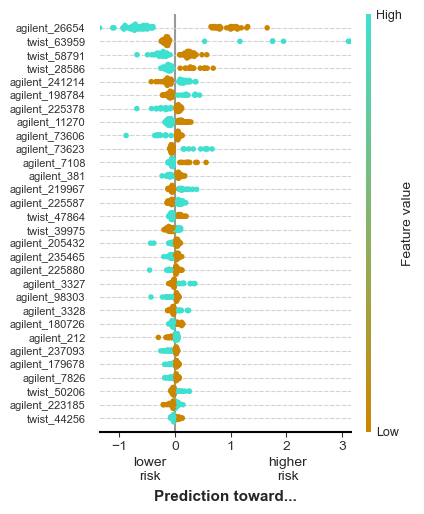

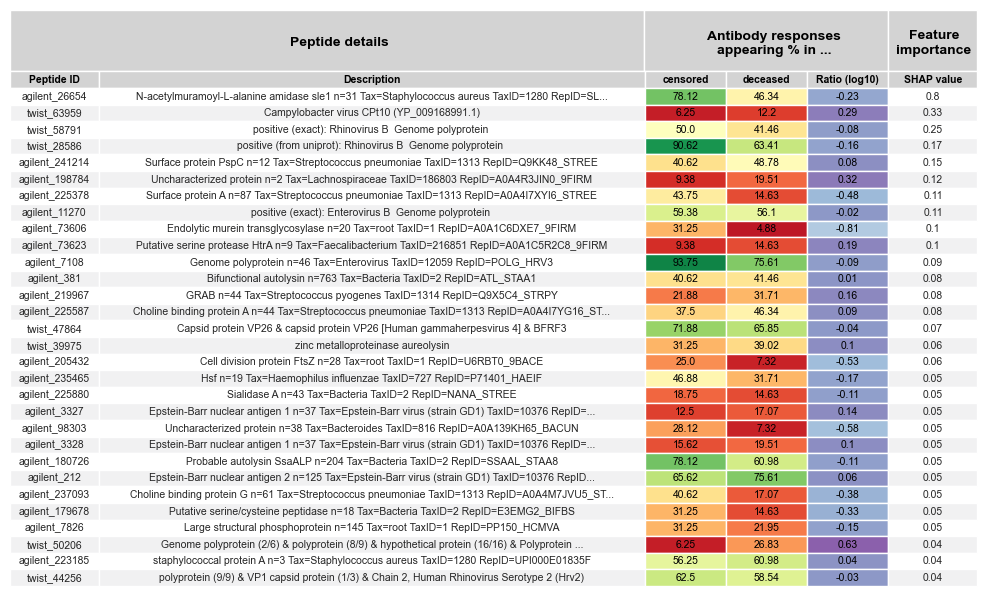

In [10]:
plot_shap_values(train_shap_values.values, X_train, cmap=newCmap, max_display=30,
                 label_groups = ['lower\nrisk', 'higher\nrisk'], suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}',
                 save_fig = False,  figures_dir = config.figures_dir )

oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]
y_event_train.name = config.col_target  # Naming the Series since it currently has no name
#features_train = X_train.join(y_event_train).set_index(config.col_target, append=True)
feature_importance_train = generate_feature_importance_table(train_shap_values.values, X_train, y_event_train, oligos_metadata,
                                                             group_tests = config.group_tests, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}', figures_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV")#config.figures_dir)
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, suffix_file =f'xgb_Cox-Hazard_trainingSet_{number_peptides}', save_fig = False)

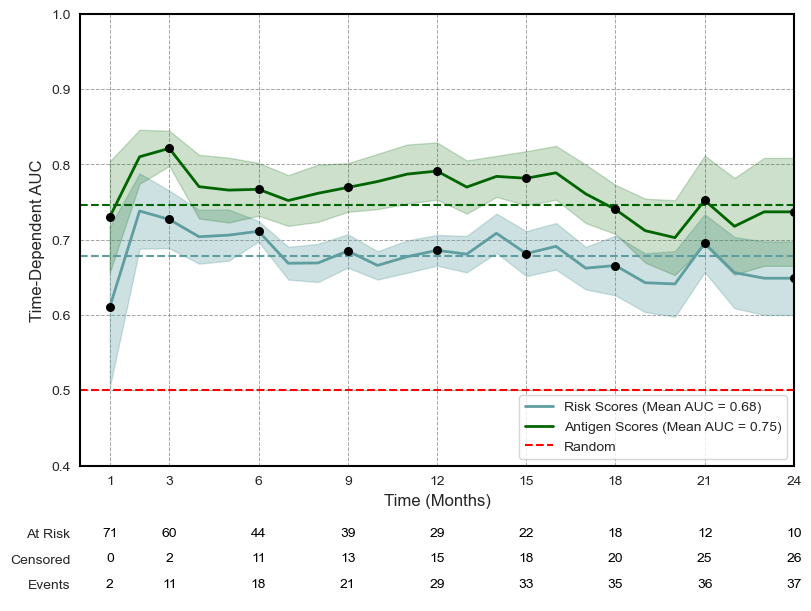

In [14]:
time_points_highlight_train = np.concatenate((([1], np.arange(3, 25, step=3))))
# Risk Scores
se_auc_curve = time_dependent_auc_train.std() / np.sqrt(time_dependent_auc_train.shape[0])
ci_lower =  np.asarray(time_dependent_auc_train.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_train.mean() + 1.96 * se_auc_curve, dtype=float)
samples_at_risk_train = calculate_samples_at_risk(y_time_train, time_points_highlight_train)
auc_values_train = time_dependent_auc_train.mean(skipna=True)

fig = plot_time_dependent_auc(auc_values_train, samples_at_risk_train,
                        mean_auc=auc_values_train.mean(),
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        time_points_highlight=time_points_highlight_train,
                        time_measure = "Months", max_time_point = 24,
                        color_auc = "CadetBlue", color_mean="CadetBlue", color_ci="CadetBlue",
                        figures_dir = config.figures_dir, save_fig=False)

# Antigen Scores
se_auc_curve = time_dependent_auc_antigen_train.std() / np.sqrt(time_dependent_auc_antigen_train.shape[0])
ci_lower =  np.asarray(time_dependent_auc_antigen_train.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_antigen_train.mean() + 1.96 * se_auc_curve, dtype=float)
auc_antigen_values_train = time_dependent_auc_antigen_train.mean(skipna=True)

ax_auc = fig.get_axes()[0]
ax_auc.plot(auc_antigen_values_train.index, auc_antigen_values_train.values, color="DarkGreen", linestyle='-', linewidth=2)
ax_auc.axhline(y=mean_auc_antigen_train.mean(), color="DarkGreen", linestyle='--', linewidth=1.5)
ax_auc.scatter(time_points_highlight_train, auc_antigen_values_train[time_points_highlight_train], color="black", s=30, zorder=3)
ax_auc.fill_between(time_points, ci_lower, ci_upper, color='DarkGreen', alpha=0.2)
ax_auc.set_ylim(0.4,1.0)
handles = ax_auc.get_lines()
handles=[handles[i] for i in [0, 3, 2]]
ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {auc_values_train.mean():.2f})",
                        f"Antigen Scores (Mean AUC = {mean_auc_antigen_train.mean():.2f})",
                        "Random"], fontsize=10, loc='lower right')

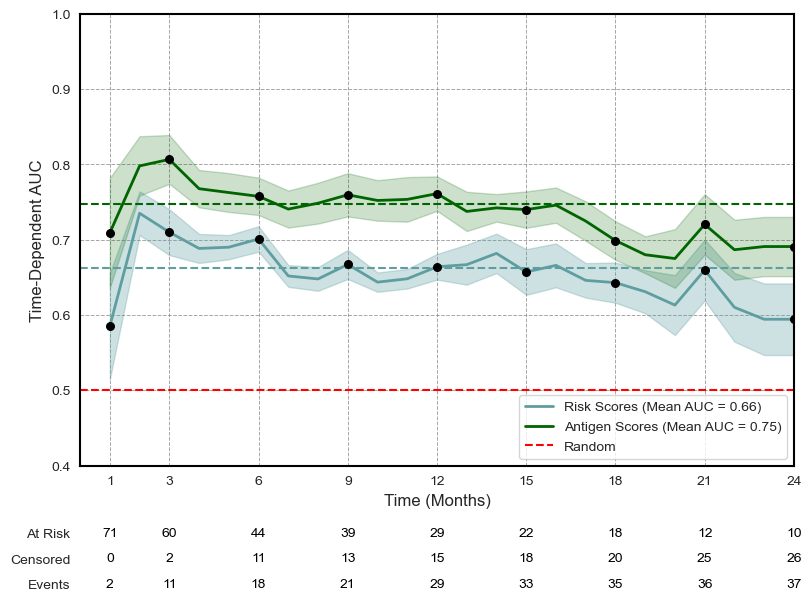

In [13]:
time_points_highlight_train = np.concatenate((([1], np.arange(3, 25, step=3))))
# Risk Scores
se_auc_curve = time_dependent_auc_train_full.std() / np.sqrt(time_dependent_auc_train_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_train_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_train_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_values_train = time_dependent_auc_train_full.mean(skipna=True)

fig = plot_time_dependent_auc(auc_values_train, samples_at_risk_train,
                        mean_auc=mean_auc_train_full.mean(),
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        time_points_highlight=time_points_highlight_train,
                        time_measure = "Months", max_time_point = 24,
                        color_auc = "CadetBlue", color_mean="CadetBlue", color_ci="CadetBlue",
                        figures_dir = config.figures_dir, save_fig=False)

# Antigen Scores
se_auc_curve = time_dependent_auc_antigen_train_full.std() / np.sqrt(time_dependent_auc_antigen_train_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_antigen_train_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_antigen_train_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_antigen_values_train = time_dependent_auc_antigen_train_full.mean(skipna=True)

ax_auc = fig.get_axes()[0]
ax_auc.plot(auc_antigen_values_train.index, auc_antigen_values_train.values, color="DarkGreen", linestyle='-', linewidth=2)
ax_auc.axhline(y=mean_auc_antigen_train_full.mean(), color="DarkGreen", linestyle='--', linewidth=1.5)
ax_auc.scatter(time_points_highlight_train, auc_antigen_values_train[time_points_highlight_train], color="black", s=30, zorder=3)
ax_auc.fill_between(time_points, ci_lower, ci_upper, color='DarkGreen', alpha=0.2)
ax_auc.set_ylim(0.4,1.0)
handles = ax_auc.get_lines()
handles=[handles[i] for i in [0, 3, 2]]
ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {mean_auc_train_full.mean():.2f})",
                        f"Antigen Scores (Mean AUC = {mean_auc_antigen_train_full.mean():.2f})",
                        "Random"], fontsize=10, loc='lower right')
save_path = Path(config.figures_dir) / f'0_test.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [66]:
antigen_scores_time_event_train = calculate_antigen_scores_scaled(train_shap_values, y_time_train.abs(), y_event_train, top_peptides_train, scaler=None, scaler_antigens=None, return_all = False)
antigen_scores_time_event_train.to_csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv", index=False)

In [ ]:
%load_ext rpy2.ipython

In [63]:
%%R -o threshold
library("maxstat")
library("survival")

df <- read.csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv")
# Create a survival object
surv_obj <- Surv(df$OS.months, df$OS.Status)
# Run the maxstat test to find the optimal cutpoint for antigen_score
result <- maxstat.test(surv_obj ~ `Antigen.Score..Scaled.`, data = df,
                       smethod = "LogRank",   # using log-rank test statistic
                       pmethod = "condMC",    # conditional Monte Carlo p-value estimation
                       B = 9999)
# Save the estimate result to a new variable
threshold <- round(result$estimate,7)[1]

In [64]:
antigen_scores_time_event_train, antigen_threshold_train, shap_scaler_train, antigen_scaler_train = calculate_antigen_scores_scaled(train_shap_values, y_time_train.abs(), y_event_train, top_peptides_train, scaler=None, scaler_antigens=None, threshold=threshold, return_all = True) #0.503159 #0.6512629
antigen_scores_time_event_train.to_csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv", index=False)

In [286]:
# auc_antigen_values_train_all, mean_auc_antigen_train_all, samples_at_risk_train = calculate_time_dependent_auc(y_time_train,
#                                                                                        y_time_train,
#                                                                                        antigen_scores_time_event_train['Antigen Score (Scaled)'],
#                                                                                        max_time_point=24,
#                                                                                        time_points_highlight=range(1,25),
#                                                                                        num_points=50, buffer=0.001)
# auc_values_train = time_dependent_auc_train_full.mean(skipna=True)
# fig = plot_time_dependent_auc(auc_values_train, samples_at_risk_train,
#                               mean_auc = mean_auc_train_full.mean(),
#                               time_points_highlight=time_points_highlight_train,
#                               time_measure = "Months", color_auc = "dodgerblue", color_mean="dodgerblue",
#                               max_time_point = 24,
#                               figures_dir = config.figures_dir, save_fig=False)
# ax_auc = fig.get_axes()[0]
# ax_auc.plot(auc_antigen_values_train_all.loc[range(1,25)].index, auc_antigen_values_train_all.loc[range(1,25)].values, color="orange", linestyle='-', linewidth=2)
# ax_auc.axhline(y=mean_auc_antigen_train_all, color="orange", linestyle='--', linewidth=1.5)
# ax_auc.scatter(time_points_highlight_train, auc_antigen_values_train_all[time_points_highlight_train], color="black", s=50, zorder=3)
# ax_auc.set_ylim(0.4,1.0)
#
# handles = ax_auc.get_lines()
# handles=[handles[i] for i in [0, 3, 2]]
# ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {mean_auc_train_full.mean():.3f})",
#                         f"Antigen Scores (Mean AUC = {mean_auc_antigen_train_all:.3f})",
#                         "Random"], fontsize=10, loc='lower right')

INFO:__main__:Log-Rank Test p-value: 0.0004


0.00036676545961483286

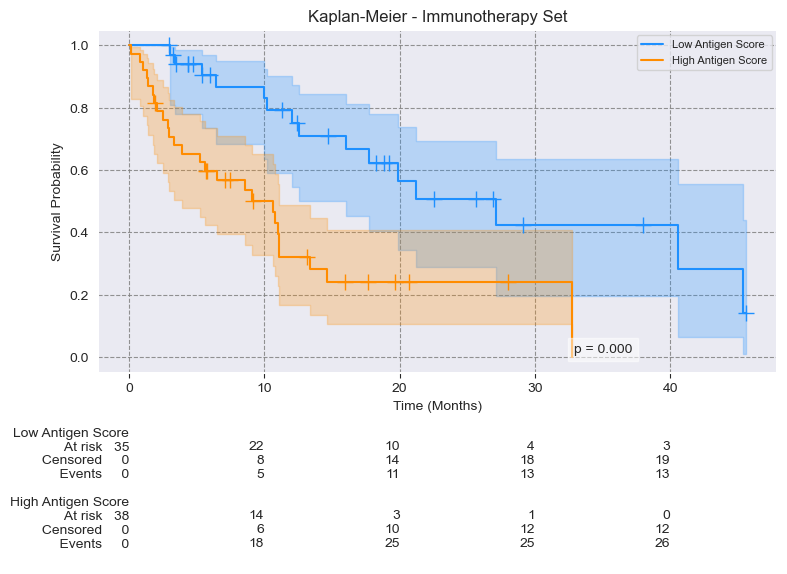

In [65]:
# Assuming the antigen score has been dichotomized into "Antigen Score (Dichotomized)"
# and you have time and event data in a data frame

# Generate Kaplan-Meier plots for Training, Testing, and Hamburg cohorts
# Define labels for high and low antigen score groups
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - Immunotherapy Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=False, figures_dir=config.figures_dir, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')
#00023073993660940222

In [48]:
top_peptides_df = feature_manager.get_data_with_target()[top_peptides_train].droplevel(0)

In [49]:
clinical_meta = metadata_handler.get_individuals_metadata_df()
clinical_meta = pd.concat([clinical_meta,
                         pd.concat([antigen_scores_time_event_train.iloc[:,2:], risk_scores_train.mean(axis=1).to_frame().rename(columns={0: "Risk Score"})], axis=1, names=["SampleName"]), top_peptides_df],  axis = 1)
# Replace 1 with the name of the peptide and 0 with "absence"
for peptide_column in top_peptides_train:
    clinical_meta[peptide_column] = clinical_meta[peptide_column].apply(
        lambda x: 'presence' if x == 1 else 'absence'
    )

In [50]:
clinical_meta['Sex_ctg'] = clinical_meta['Sex'].apply(lambda x: "Male" if x == 1 else "Female")

#clinical_meta['Age >= 65'] = (clinical_meta['Age']>=65).astype(int)
clinical_meta['Age_ctg'] = clinical_meta['Age'].apply(lambda x: ">=65" if x >=65 else "<65")

clinical_meta['AFP 100_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=100" if x >=100 else "<100")
clinical_meta['AFP 400_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=400" if x >=400 else "<400")

clinical_meta["Line_of_syst.treatment"] = pd.get_dummies(clinical_meta["Line_of_syst.treatment_ctg"], drop_first=True, dtype=int)

clinical_meta["BMI Category"] = clinical_meta["BMI"].apply(lambda x: "<18.5" if x < 18.5 else
                                                        ">=18.5<25" if x >= 18.5 and x < 25 else
                                                        ">=25<30" if x >= 25 and x < 30 else
                                                        ">=30<35" if x >= 30 and x < 35 else
                                                        ">=35")
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BMI Category"], drop_first=False, dtype=int).drop(columns=[">=18.5<25"])], axis =1)

clinical_meta['Cirrhosis_ctg'] = clinical_meta['Cirrhosis_ctg'].apply(lambda x: "cirrhosis" if x == "yes" else "no cirrhosis")
clinical_meta['Cirrhosis_ctg'] = pd.Categorical(clinical_meta['Cirrhosis_ctg'],
                                                     categories=["no cirrhosis","cirrhosis"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["Child-Pugh stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage B": "Child-Pugh stage B"})], axis=1)
clinical_meta['MVI_ctg'] = clinical_meta['MVI_ctg'].apply(lambda x: "MVI" if x == "yes" else "no MVI")
clinical_meta['MVI_ctg'] = pd.Categorical(clinical_meta['MVI_ctg'],
                                                     categories=["no MVI","MVI"], ordered=True)
clinical_meta['EHS_ctg'] = clinical_meta['EHS_ctg'].apply(lambda x: "EHS" if x == "yes" else "no EHS")
clinical_meta['EHS_ctg'] = pd.Categorical(clinical_meta['EHS_ctg'],
                                                     categories=["no EHS","EHS"], ordered=True)

# Merge "stage A" and "stage B" into "stage AB"
clinical_meta['BCLC stage_ctg'] = clinical_meta['BCLC stage_ctg'].replace({'stage A': 'stage AB', 'stage B': 'stage AB'})
clinical_meta['BCLC stage_ctg'] = pd.Categorical(clinical_meta['BCLC stage_ctg'],
                                                     categories=["stage AB", "stage C"], ordered=True)
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BCLC stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage C": "BCLC stage C"})], axis=1)

clinical_meta['Antigen Score (Dichotomized) ctg'] = clinical_meta['Antigen Score (Dichotomized)'].apply(lambda x: "Low Antigen Score" if x == 0 else "High Antigen Score")
clinical_meta['Antigen Score (Dichotomized) ctg'] = pd.Categorical(clinical_meta['Antigen Score (Dichotomized) ctg'],
                                                     categories=["Low Antigen Score", "High Antigen Score"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["mRECIST_ctg"], drop_first=True, dtype=int)], axis = 1)#.drop(columns=["CR"])], axis=1)
#clinical_meta['mRECIST_ctg'] = pd.Categorical(clinical_meta['mRECIST_ctg'],
#                                                     categories=["PR", "CR", "SD", "PD"], ordered=True)
#clinical_meta.to_excel("/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Metadata/HCC_MUW_metadata_with_scores.xlsx", index=True)

In [849]:
# Define your list of variables (including any top peptides if needed)
variables = [
    "Sex_ctg", "Age_ctg", "ORR_ctg", "DCR_ctg", "Line_of_syst.treatment_ctg",
    "Cirrhosis_ctg", "Child-Pugh stage_ctg", "ECOG_ctg", "MVI_ctg", "EHS_ctg", "BCLC stage_ctg",
    "AFP 100_ctg", "AFP 400_ctg", "Antigen Score (Dichotomized) ctg",
    *list(top_peptides_train)  # assuming top_peptides_train is defined
]

# Run the univariate analysis function
univariate_results, univariate_kmf  = run_univariate_km_analysis(clinical_meta, variables, config.figures_dir, f"{number_peptides}")

# Now univariate_results is a DataFrame summarizing the key findings.
#print(univariate_results)
print(tabulate(univariate_kmf, headers='keys', tablefmt='latex', showindex=False))
significant_predictors_kmf = univariate_results[univariate_results["P-value"] < 0.1]["Variable"].unique().tolist()
significant_predictors_kmf

KeyError: 'Sex_ctg'

In [51]:
predictors_cont = ["Age", "AFP", "Antigen Score (Scaled)"]

# predictors for categorical variables:
predictors_ctg = {
    "Sex_ctg": "Female",
    "Age_ctg": "<65",
    "ORR_ctg": "ORR",
    "DCR_ctg": "DCR",
    "Line_of_syst.treatment_ctg": "first",
    "Cirrhosis_ctg": "no cirrhosis",
    "Child-Pugh stage_ctg": "A",
    "ECOG_ctg": "no symptoms",
    "MVI_ctg": "no MVI",
    "EHS_ctg": "no EHS",
    "BCLC stage_ctg": "AB",
    "AFP 100_ctg": "<100",
    "AFP 400_ctg": "<400",
    "Antigen Score (Dichotomized) ctg": "Low"
}
predictors_ctg.update({variable: "absence" for variable in list(top_peptides_train)})

# Run the univariate analysis:
univariate_results, univariate_cph = run_univariate_cox_analysis(clinical_meta, predictors_cont, predictors_ctg)
significant_predictors_cph = univariate_results[univariate_results["P-value"] < 0.1]["Variable"].tolist()
print(tabulate(univariate_cph, headers='keys', tablefmt='latex', showindex=False))

\begin{tabular}{llrrrl}
\hline
 Variable                  & Group                            &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper & P-value         \\
\hline
 Age                       &                                  &           1    &           0.96 &           1.03 & 0.7783          \\
 \textbackslash{}textbf\{AFP\}              &                                  &           1    &           1    &           1    & \textbackslash{}textbf\{0.0112\} \\
 \textbackslash{}textbf\{Antigen Score\}    &                                  &           5.92 &           1.45 &          24.25 & \textbackslash{}textbf\{0.0134\} \\
 Sex                       & Male - Ref Female                &           1.05 &           0.51 &           2.15 & 0.8954          \\
                           & \ensuremath{>}=65 - Ref \ensuremath{<}65                   &           0.94 &           0.49 &           1.83 & 0.8597          \\
 \textbackslash{}textbf\{ORR\}              & \textbackslash{}

In [52]:
# Function to extract the first and second parts
def extract_parts(text):
    pattern = r'C\(`([^`]+)`\)\[T\.([^\]]+)\]'
    match = re.match(pattern, text)
    if match:
        return match.groups()  # returns a tuple (first_part, second_part)
    else:
        return text, ''  # If it doesn't match the pattern, return the original text and an empty string

references_dict = {"Sex":"Female", "Age":"<65", "ORR":"ORR", "DCR":"DCR",
                 "Line_of_syst.treatment":"first", "Cirrhosis":"no cirrhosis",
                 "Child-Pugh stage":"A", "ECOG":"no symptoms" , "MVI":"no MVI", "EHS":"no EHS",
                 "BCLC stage":"AB", "AFP 100":"<100", "AFP 400":"<400",
                  "Antigen Score": "Low"}
references_dict.update({variable: "absence" for variable in list(top_peptides_train)})

# Step 1: Perform univariate analysis to select initial candidate variables
#significant_predictors = [significant_predictors_cph[i] for i in [4,5,7,8]]
significant_predictors = ['Child-Pugh stage', 'MVI', 'AFP 400', 'Antigen Score']
significant_predictors = [key for key in predictors_ctg if any(value in key for value in significant_predictors)] #+ ['Antigen Score (Scaled)']
continuous_predictors = ['Sex', 'AFP', 'Antigen Score (Scaled)']

# Step 2: Fit Cox model with all candidate variables
cph = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in significant_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in significant_predictors])
cph.fit(clinical_meta[["OS months", "OS Status"] + significant_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)


# Step 3: Start the backward selection process
selected_predictors = significant_predictors.copy()
best_aic = cph.AIC_partial_

# Conditional Backward Selection Loop
while len(selected_predictors) > 0:
    aic_with_candidates = []
    # Loop through each predictor and remove it, refit the model, and calculate AIC
    for predictor in selected_predictors:
        predictors_to_fit = [p for p in selected_predictors if p != predictor]

        cph = CoxPHFitter()

        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in predictors_to_fit])
        #formula = " + ".join([f"C(`{p}`)" for p in predictors_to_fit])
        cph.fit(clinical_meta[["OS months", "OS Status"] + predictors_to_fit],
                duration_col="OS months", event_col="OS Status", formula=formula)

        # Store the AIC for this candidate model
        aic_with_candidates.append((cph.AIC_partial_, predictor))

    # Sort by AIC and select the model with the smallest AIC
    aic_with_candidates.sort()
    best_new_aic, best_candidate_to_remove = aic_with_candidates[0]

    # If the best model with one less predictor has a better AIC, remove the variable
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors.remove(best_candidate_to_remove)
        print(f"Removed {best_candidate_to_remove}, AIC: {best_aic}")
    else:
        break  # Stop if no improvement

# Final Model with selected predictors
#selected_predictors = selected_predictors + ['Antigen Score (Dichotomized) ctg']
print("Final Model Predictors:", selected_predictors)

# Fit the final Cox model with the selected predictors
cph_bwd = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_bwd.fit(clinical_meta[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)
# Print the final model summary
cph_bwd.print_summary()


multivariate_results = []
summary = cph_bwd.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']

    variable, category = extract_parts(idx)

    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    if category != '' :
        category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    else:
        category_name = ''
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_bwd_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
multivariate_bwd_cph['Hazard Ratio'] = multivariate_bwd_cph['Hazard Ratio'].round(2)
multivariate_bwd_cph['95% CI Lower'] = multivariate_bwd_cph['95% CI Lower'].round(2)
multivariate_bwd_cph['95% CI Upper'] = multivariate_bwd_cph['95% CI Upper'].round(2)
multivariate_bwd_cph['Coef'] = multivariate_bwd_cph['Coef'].round(2)
multivariate_bwd_cph['P-value'] = multivariate_bwd_cph['P-value'].round(4)

print(tabulate(multivariate_bwd_cph, headers='keys', tablefmt='latex', showindex=False))

# Prepare the external validation set (clinical_meta_validation)
#y_surv_train = Surv.from_arrays(event=clinical_meta["OS Status"], time=clinical_meta["OS months"])
#y_surv_val = Surv.from_arrays(event=clinical_meta_validation["OS Status"], time=clinical_meta_validation["OS months"])

#validation_data = clinical_meta_validation[["OS months", "OS Status"] + selected_predictors]
#predicted_risk_scores_bwd = cph_bwd.predict_partial_hazard(validation_data)

# Calculate the C-index on the external validation set
#c_index_external = concordance_index_ipcw(y_surv_train, y_surv_val, predicted_risk_scores_bwd)[0]
#print(f"C-index on the external validation set: {c_index_external:.4f}")
#C-index on the external validation set:
# AIC: 254.86
#Final Model Predictors: ['Child-Pugh stage_ctg', 'AFP 400', 'Antigen Score (Dichotomized) ctg']

Removed MVI_ctg, AIC: 253.30992437458883
Final Model Predictors: ['Child-Pugh stage_ctg', 'AFP 400_ctg', 'Antigen Score (Dichotomized) ctg']


<lifelines.CoxPHFitter: fitted with 73 total observations, 32 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 73
number of events observed = 41
   partial log-likelihood = -123.65
         time fit was run = 2025-03-25 13:51:23 UTC

---
                                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                    
C(`Child-Pugh stage_ctg`)[T.stage B]                         1.56      4.74      0.36            0.86            2.26                2.35                9.57
C(`AFP 400_ctg`)[T.>=400]                                    1.04      2.83      0.36            0.34            1.74                1.40                5.70
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]  1.13      3.10      0.38            0.39            1.87                1.48                6.49

                                                             cmp to    z      p  -log2(p)
covariate                                                                                
C(`Child-Pugh stage_ctg`)[T.stage B]                           0.00 4.35 <0.005     16.17
C(`AFP 400_ctg`)[T.>=400]                                      0.00 2.91 <0.005      8.10
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]    0.00 2.99 <0.005      8.50
---
Concordance = 0.79
Partial AIC = 253.31
log-likelihood ratio test = 39.66 on 3 df
-log2(p) of ll-ratio test = 26.24

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group            &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &   Coef &   Score points &   P-value \\
\hline
 Child-Pugh stage & B - Ref A        &           4.74 &           2.35 &           9.57 &   1.56 &            3.2 &    0      \\
 AFP 400          & \ensuremath{>}=400 - Ref \ensuremath{<}400 &           2.83 &           1.4  &           5.7  &   1.04 &            2.1 &    0.0036 \\
 Antigen Score    & High - Ref Low   &           3.1  &           1.48 &           6.49 &   1.13 &            2.3 &    0.0028 \\
\hline
\end{tabular}


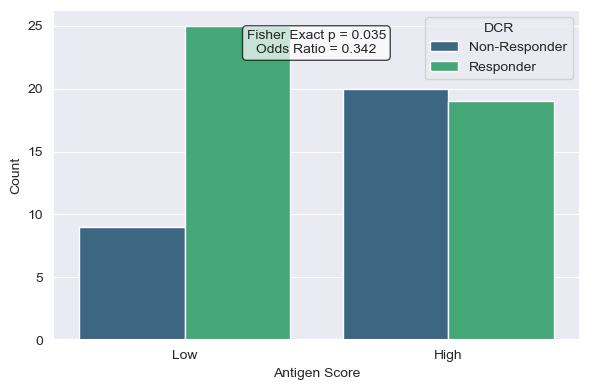

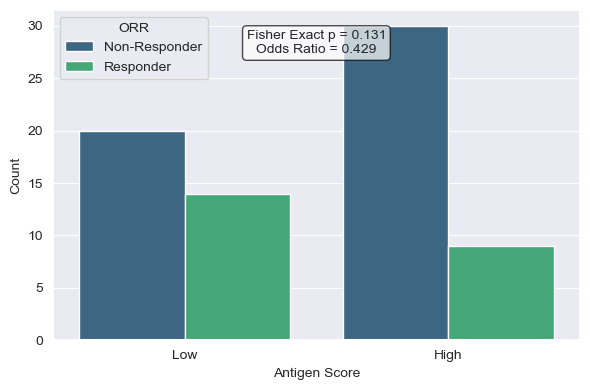

In [53]:
mapping = {0.0: 'Non-Responder', 1.0: 'Responder'}
mapping_antigen = {0: 'Low', 1: 'High'}

# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='DCR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    x_label='Antigen Score',
    #title='Disease Control Rate by Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    #save_path=config.figures_dir,
    #suffix_file=f"antigenScore_DCR_{number_peptides}"
)
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    x_label='Antigen Score',
    #title='Disease Control Rate by Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    #save_path=config.figures_dir,
    #suffix_file=f"antigenScore_ORR_{number_peptides}"
)

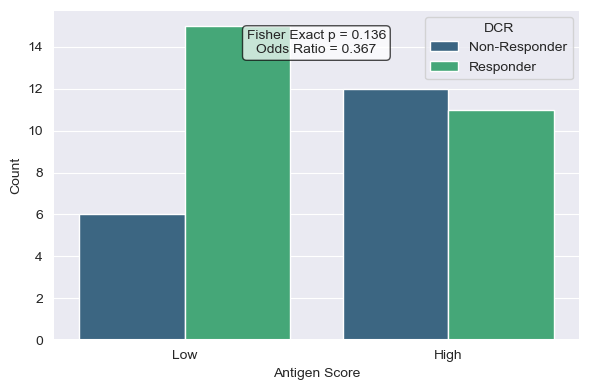

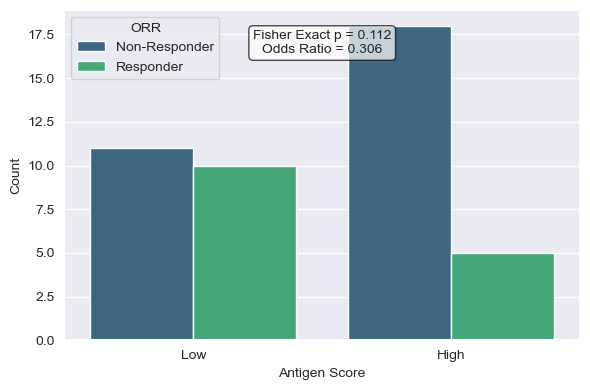

In [54]:
child_pugh_A_df = clinical_meta[clinical_meta['Child-Pugh stage'] == 1]
mapping = {0.0: 'Non-Responder', 1.0: 'Responder'}
mapping_antigen = {0: 'Low', 1: 'High'}

# Call the function1
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='DCR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    x_label='Antigen Score',
    #title='Disease Control Rate by Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    #save_path=config.figures_dir,
    #suffix_file=f"childPughA_antigenScore_DCR_{number_peptides}"
)

# Call the function
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    x_label='Antigen Score',
    #title='Disease Control Rate by Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    #save_path=config.figures_dir,
    #suffix_file=f"childPughA_antigenScore_ORR_{number_peptides}"
)

Mann–Whitney Test statistic: 804.0, p-value: 0.062
Mann–Whitney Test statistic: 677.0, p-value: 0.228


/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119

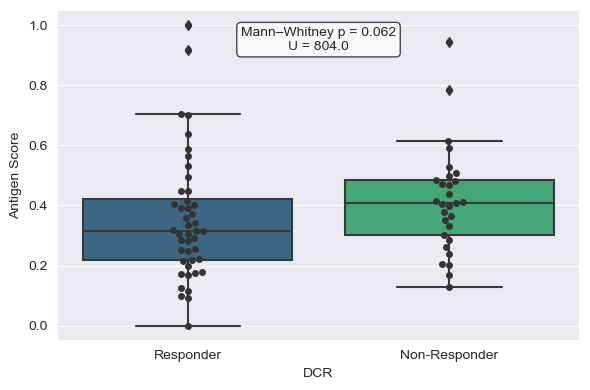

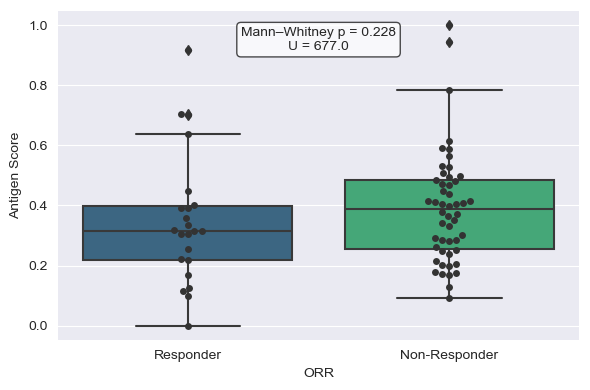

In [55]:
mapping_dcr = {0: 'Non-Responder', 1: 'Responder'}

fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               cat_var='DCR',
                                               cat_mapping=mapping_dcr,
                                               x_label="DCR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(6,4),
                                              # save_path=config.figures_dir,
                                              # suffix_file=f"antigenScore_DCR_{number_peptides}"
                                               )

fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               cat_var='ORR',
                                               cat_mapping=mapping_dcr,
                                               x_label="ORR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(6,4),
                                               #save_path=config.figures_dir,
                                               #suffix_file=f"antigenScore_ORR_{number_peptides}"
                                               )